# Integrated Gradients explanation for MCI classification on NNConv model

This notebook applies Integrated Gradients to the selected NNConv graph classifier.


In [1]:
!pip install torch-geometric -q
!pip install networkx pandas -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.6 MB/s eta 0:00:00


In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from google.colab import drive
from torch_geometric.nn import global_mean_pool, global_max_pool


In [3]:
drive.mount('/content/drive')

torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


Mounted at /content/drive
Using device: cuda


### Model definition


In [4]:
class NNConvLayer(nn.Module):
    def __init__(self, node_dim, edge_dim, out_dim):
        super().__init__()
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, node_dim * out_dim)
        )
        self.node_dim = node_dim
        self.out_dim  = out_dim
        self.gru = nn.GRUCell(out_dim, node_dim)

    def forward(self, x, edge_index, edge_attr):
        src, dst = edge_index
        num_nodes = x.size(0)
        W = self.edge_mlp(edge_attr).view(-1, self.node_dim, self.out_dim)
        h_src = x[src].unsqueeze(1)
        msg   = torch.bmm(h_src, W).squeeze(1)
        agg   = torch.zeros(num_nodes, self.out_dim, device=x.device)
        agg.scatter_add_(0, dst.unsqueeze(-1).expand_as(msg), msg)
        return self.gru(agg, x)


class NNConvNet(nn.Module):
    def __init__(self, node_in, edge_in, hidden, dropout):
        super().__init__()
        self.input_proj = nn.Linear(node_in, hidden)
        self.input_norm = nn.BatchNorm1d(hidden)
        self.conv1 = NNConvLayer(hidden, edge_in, hidden)
        self.norm1 = nn.BatchNorm1d(hidden)
        self.conv2 = NNConvLayer(hidden, edge_in, hidden)
        self.norm2 = nn.BatchNorm1d(hidden)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2),
        )

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.input_proj(x)
        x = self.input_norm(x)
        x = x.relu()
        x = self.conv1(x, edge_index, edge_attr)
        x = self.norm1(x)
        x = x.relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = x.relu()
        x = self.dropout(x)
        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=-1)
        return self.classifier(x)


### Defining paths, feature names, and loading the selected model


In [5]:
MODEL_PATH = '/content/drive/MyDrive/team3_xai_gnn/nnconv_results/outer_checkpoints/cfg00_outer1.pt'
PREPROCESSED_DIR = '/content/drive/MyDrive/team3_xai_gnn/preprocessed'
TRAIN_PATH = os.path.join(PREPROCESSED_DIR, 'fold_1_train.pt')
VAL_PATH   = os.path.join(PREPROCESSED_DIR, 'fold_1_val.pt')
TEST_PATH  = os.path.join(PREPROCESSED_DIR, 'fold_1_test.pt')
DMRI_PATH  = '/content/drive/MyDrive/team3_xai_gnn/oasis3_graphmls_scale1'

NODE_FEATURE_NAMES = ['volume', 'thickness', 'has_volume', 'has_thickness']

model = NNConvNet(node_in=4, edge_in=15, hidden=32, dropout=0.3)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()
print('NNConv model loaded.')


NNConv model loaded.


### Loading data and ROI labels


In [6]:
def load_graphs(path):
    if not os.path.exists(path):
        print(f'File not found: {path}')
        return []
    return torch.load(path, map_location=DEVICE, weights_only=False)

train_graphs = load_graphs(TRAIN_PATH)
val_graphs   = load_graphs(VAL_PATH)
test_graphs  = load_graphs(TEST_PATH)

if len(test_graphs) == 0:
    raise RuntimeError('No test graphs found. Check TEST_PATH.')

sample_graph = test_graphs[0]

print(f'Train subjects: {len(train_graphs)}')
print(f'Val subjects:   {len(val_graphs)}')
print(f'Test subjects:  {len(test_graphs)}')
print('Sample x shape:', tuple(sample_graph.x.shape))
print('Sample edge_index shape:', tuple(sample_graph.edge_index.shape))
print('Sample edge_attr shape:', tuple(sample_graph.edge_attr.shape) if sample_graph.edge_attr is not None else None)

# ROI names from the GraphML files.
graphml_files = [f for f in os.listdir(DMRI_PATH) if f.endswith('.graphml')] if os.path.exists(DMRI_PATH) else []
if len(graphml_files) == 0:
    node_labels = {i: f'Node {i}' for i in range(sample_graph.x.size(0))}
    print('No GraphML files found. Falling back to generic node labels.')
else:
    sample_G = nx.read_graphml(os.path.join(DMRI_PATH, graphml_files[0]))
    sample_G.remove_edges_from(list(nx.selfloop_edges(sample_G)))
    nodes = list(sample_G.nodes(data=True))
    node_labels = {i: attrs.get('dn_name', f'node_{i}').strip() for i, (_, attrs) in enumerate(nodes)}
    print(f'Node label map built: {len(node_labels)} ROIs')


def _as_clean_list(value):
    """Normalize possible metadata containers into a clean list of strings."""
    if value is None:
        return None
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu().tolist()
    if isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, str):
        # Some datasets store feature names as comma-separated strings.
        for sep in ['|', ',', ';']:
            if sep in value:
                return [v.strip() for v in value.split(sep) if v.strip()]
        return [value.strip()]
    if isinstance(value, dict):
        # Common format: {0: 'FA', 1: 'MD', ...}
        try:
            return [str(value[k]) for k in sorted(value.keys(), key=lambda x: int(x))]
        except Exception:
            return [str(v) for v in value.values()]
    if isinstance(value, (list, tuple)):
        return [str(v).strip() for v in value]
    return None


def _try_float(value):
    try:
        if value is None:
            return None
        return float(value)
    except Exception:
        return None


def _metadata_edge_feature_names(graph, n_features):
    """Look for edge-feature names saved directly in the PyG graph object."""
    candidate_keys = [
        'edge_feature_names', 'edge_attr_names', 'edge_features', 'edge_columns',
        'edge_feature_cols', 'edge_attr_cols', 'edge_feature_labels', 'edge_attr_labels',
        'feature_names', 'feature_cols'
    ]
    for key in candidate_keys:
        if hasattr(graph, key):
            names = _as_clean_list(getattr(graph, key))
            if names and len(names) == n_features:
                print(f'Using edge-feature names from sample_graph.{key}.')
                return names, f'sample_graph.{key}'
    return None, None


def _choose_matching_graphml_file(graphml_files, graph):
    """Prefer a GraphML file whose filename contains the current subject id, otherwise use the first file."""
    subject_id = str(getattr(graph, 'subject_id', '')).strip()
    if subject_id:
        for filename in graphml_files:
            if subject_id in filename:
                return filename
    return graphml_files[0] if graphml_files else None


def _numeric_edge_keys_in_order(G):
    """
    Return numeric edge-attribute keys in their first-seen GraphML order.
    Non-numeric attributes such as labels are ignored.
    """
    keys = []
    for _, _, attrs in G.edges(data=True):
        for key, value in attrs.items():
            if key not in keys and _try_float(value) is not None:
                keys.append(key)
    return keys



def _aligned_graphml_edge_table(G, graph, numeric_keys, max_edges=2000):
    """
    Align GraphML numeric edge attributes with the PyG edge order.
    Returns (pyg_matrix, graphml_matrix, used_keys).

    This lets us infer which GraphML attribute corresponds to each edge_attr column,
    even when one GraphML numeric attribute was removed during preprocessing.
    """
    if graph.edge_attr is None:
        return None, None, []

    edge_index_cpu = graph.edge_index.detach().cpu()
    edge_attr_cpu = graph.edge_attr.detach().cpu().numpy().astype(float)
    graphml_nodes = list(G.nodes())

    pyg_rows = []
    graphml_rows = []

    n_edges = min(max_edges, edge_index_cpu.size(1))
    for edge_pos in range(n_edges):
        src_idx = int(edge_index_cpu[0, edge_pos].item())
        dst_idx = int(edge_index_cpu[1, edge_pos].item())

        if src_idx >= len(graphml_nodes) or dst_idx >= len(graphml_nodes):
            continue

        u = graphml_nodes[src_idx]
        v = graphml_nodes[dst_idx]
        attrs = G.get_edge_data(u, v)
        if attrs is None:
            attrs = G.get_edge_data(v, u)
        if attrs is None:
            continue

        vals = []
        ok = True
        for key in numeric_keys:
            val = _try_float(attrs.get(key))
            if val is None:
                ok = False
                break
            vals.append(val)

        if ok:
            pyg_rows.append(edge_attr_cpu[edge_pos])
            graphml_rows.append(vals)

    if not pyg_rows:
        return None, None, []

    return np.asarray(pyg_rows, dtype=float), np.asarray(graphml_rows, dtype=float), list(numeric_keys)


def _safe_corr(a, b):
    """Correlation that tolerates constant columns."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])


def _infer_edge_feature_names_by_correlation(G, graph, numeric_keys, min_abs_corr=0.98):
    """
    Infer edge_attr column names by correlating each PyG edge_attr column with
    every numeric GraphML edge attribute across aligned edges.

    This works even if preprocessing standardized or normalized the values,
    because correlation is invariant to linear scaling.
    """
    n_features = int(graph.edge_attr.size(-1))
    pyg_matrix, graphml_matrix, used_keys = _aligned_graphml_edge_table(G, graph, numeric_keys)

    if pyg_matrix is None or graphml_matrix is None:
        return None, None, None

    if pyg_matrix.shape[1] != n_features:
        return None, None, None

    corr = np.zeros((n_features, len(used_keys)), dtype=float)
    for i in range(n_features):
        for j, key in enumerate(used_keys):
            corr[i, j] = _safe_corr(pyg_matrix[:, i], graphml_matrix[:, j])

    # Greedy one-to-one assignment. Small matrix, and this is enough for strongly matched columns.
    assignments = {}
    used_graphml_cols = set()
    pairs = []
    for i in range(n_features):
        for j in range(len(used_keys)):
            pairs.append((abs(corr[i, j]), corr[i, j], i, j))
    pairs.sort(reverse=True, key=lambda x: x[0])

    for abs_c, raw_c, i, j in pairs:
        if i in assignments or j in used_graphml_cols:
            continue
        if abs_c >= min_abs_corr:
            assignments[i] = (j, raw_c)
            used_graphml_cols.add(j)
        if len(assignments) == n_features:
            break

    if len(assignments) != n_features:
        # Return the diagnostic matrix even if automatic mapping is not safe.
        corr_df = pd.DataFrame(
            corr,
            index=[f'edge_attr_{i}' for i in range(n_features)],
            columns=used_keys,
        )
        return None, corr_df, None

    ordered_names = []
    rows = []
    for i in range(n_features):
        j, raw_c = assignments[i]
        ordered_names.append(used_keys[j])
        rows.append({
            'edge_feature_index': i,
            'edge_feature_name': used_keys[j],
            'correlation_with_edge_attr_column': raw_c,
        })

    dropped_keys = [key for j, key in enumerate(used_keys) if j not in used_graphml_cols]
    mapping_df = pd.DataFrame(rows)
    return ordered_names, mapping_df, dropped_keys


def infer_edge_feature_names(sample_graph, dmri_path, graphml_files):
    """
    Infer names for sample_graph.edge_attr dimensions.

    Priority:
    1. names stored in the PyG graph object;
    2. correlation-based matching between PyG edge_attr columns and GraphML numeric edge attributes;
    3. exact-count GraphML fallback;
    4. safe generic fallback.
    """
    n_features = int(sample_graph.edge_attr.size(-1))

    names, source = _metadata_edge_feature_names(sample_graph, n_features)
    if names is not None:
        return names, source

    if graphml_files:
        chosen_file = _choose_matching_graphml_file(graphml_files, sample_graph)
        graphml_path = os.path.join(dmri_path, chosen_file)
        G = nx.read_graphml(graphml_path)
        G.remove_edges_from(list(nx.selfloop_edges(G)))
        numeric_keys = _numeric_edge_keys_in_order(G)

        print(f'GraphML file inspected for edge-feature names: {chosen_file}')
        print(f'Numeric GraphML edge attributes found ({len(numeric_keys)}): {numeric_keys}')

        # Known preprocessing for this dataset:
        # fiber_density is removed because normalized_fiber_density is already included.
        if len(numeric_keys) == n_features + 1 and 'fiber_density' in numeric_keys:
            candidate = [k for k in numeric_keys if k != 'fiber_density']
            if len(candidate) == n_features:
                print('Using GraphML numeric attributes after excluding fiber_density.')
                print('This matches the preprocessing report: fiber_density is removed because normalized_fiber_density is used.')
                print("GraphML numeric attribute not used in edge_attr: ['fiber_density']")
                return candidate, f'GraphML attributes excluding fiber_density from {chosen_file}'

        # First try the robust case: match columns by correlation.
        inferred_names, diagnostic_df, dropped_keys = _infer_edge_feature_names_by_correlation(
            G, sample_graph, numeric_keys, min_abs_corr=0.98
        )
        if inferred_names is not None and len(inferred_names) == n_features:
            print('Using correlation-matched GraphML attributes as EDGE_FEATURE_NAMES.')
            if dropped_keys:
                print(f'GraphML numeric attribute not used in edge_attr: {dropped_keys}')
            print('\nEdge-feature mapping inferred from value correlations:')
            display(diagnostic_df)
            return inferred_names, f'correlation-matched GraphML attributes from {chosen_file}'

        if diagnostic_df is not None:
            print('Automatic correlation matching was not confident enough.')
            print('Correlation diagnostic table below can be used to inspect possible matches manually:')
            display(diagnostic_df.round(3))

        # If counts happen to match, use the GraphML order as a fallback.
        if len(numeric_keys) == n_features:
            print('Using GraphML numeric edge-attribute order as EDGE_FEATURE_NAMES.')
            return numeric_keys, f'GraphML numeric edge attributes from {chosen_file}'

        print('Could not safely map GraphML edge attributes to edge_attr dimensions automatically.')
        print(f'edge_attr has {n_features} columns but GraphML exposes {len(numeric_keys)} numeric edge attributes.')
        print('Keeping generic labels. If you know the preprocessing order, set EDGE_FEATURE_NAMES manually below.')

    return [f'Edge feature {i}' for i in range(n_features)], 'generic fallback'


EDGE_FEATURE_NAMES, EDGE_FEATURE_NAME_SOURCE = infer_edge_feature_names(sample_graph, DMRI_PATH, graphml_files)
print('\nFinal EDGE_FEATURE_NAMES source:', EDGE_FEATURE_NAME_SOURCE)
print(pd.DataFrame({
    'edge_feature_index': list(range(len(EDGE_FEATURE_NAMES))),
    'edge_feature_name': EDGE_FEATURE_NAMES,
}))


Train subjects: 431
Val subjects:   77
Test subjects:  127
Sample x shape: (124, 4)
Sample edge_index shape: (2, 6380)
Sample edge_attr shape: (6380, 15)
Node label map built: 124 ROIs
GraphML file inspected for edge-feature names: sub-OAS30002_ses-d2340_atlas-L2018_res-scale1_conndata-network_connectivity.graphml
Numeric GraphML edge attributes found (16): ['number_of_fibers', 'fiber_length_mean', 'fiber_length_median', 'fiber_length_std', 'fiber_proportion', 'fiber_density', 'normalized_fiber_density', 'shore_gfa_mean', 'shore_gfa_std', 'shore_gfa_median', 'shore_msd_mean', 'shore_msd_std', 'shore_msd_median', 'shore_rtop_signal_mean', 'shore_rtop_signal_std', 'shore_rtop_signal_median']
Using GraphML numeric attributes after excluding fiber_density.
This matches the preprocessing report: fiber_density is removed because normalized_fiber_density is used.
GraphML numeric attribute not used in edge_attr: ['fiber_density']

Final EDGE_FEATURE_NAMES source: GraphML attributes excluding f

### Integrated Gradients baseline

This version of Integrated Gradients is computed against a **global training-set mean baseline** instead of a zero baseline. might be more useful info wise than the previous zero version

In [7]:

def build_mean_ig_baseline(train_graphs, reference_graph, device):
    """
    Build a mean baseline for Integrated Gradients.

    Node baseline:
      - If training graphs have the same node-feature shape as the reference graph,
        use the ROI-wise mean: [num_nodes, num_node_features].
      - Otherwise, fall back to feature-wise mean: [num_node_features],
        expanded later.

    Edge baseline:
      - Use feature-wise mean across all training edges: [num_edge_features].
      - This avoids requiring all graphs to have the same number of edges.
    """

    reference_x_shape = tuple(reference_graph.x.shape)
    node_feature_dim = reference_graph.x.size(-1)
    edge_feature_dim = reference_graph.edge_attr.size(-1)

    xs_same_shape = []
    xs_featurewise = []
    edge_attrs = []

    for g in train_graphs:
        if hasattr(g, "x") and g.x is not None and g.x.size(-1) == node_feature_dim:
            if tuple(g.x.shape) == reference_x_shape:
                xs_same_shape.append(g.x.detach().float().cpu())
            xs_featurewise.append(g.x.detach().float().cpu().reshape(-1, node_feature_dim))

        if hasattr(g, "edge_attr") and g.edge_attr is not None and g.edge_attr.size(-1) == edge_feature_dim:
            edge_attrs.append(g.edge_attr.detach().float().cpu().reshape(-1, edge_feature_dim))

    if xs_same_shape:
        mean_x = torch.stack(xs_same_shape, dim=0).mean(dim=0)
        node_baseline_mode = "roi_wise_training_mean"
    elif xs_featurewise:
        mean_x = torch.cat(xs_featurewise, dim=0).mean(dim=0)
        node_baseline_mode = "feature_wise_training_mean"
    else:
        raise RuntimeError("No usable training node features found for the mean baseline.")

    if not edge_attrs:
        raise RuntimeError("No usable training edge features found for the mean baseline.")

    mean_edge_attr = torch.cat(edge_attrs, dim=0).mean(dim=0)

    print("Mean IG baseline built.")
    print("Node baseline mode:", node_baseline_mode)
    print("Mean node baseline shape:", tuple(mean_x.shape))
    print("Mean edge baseline shape:", tuple(mean_edge_attr.shape))

    return mean_x.to(device), mean_edge_attr.to(device)


MEAN_BASELINE_X, MEAN_BASELINE_EDGE_ATTR = build_mean_ig_baseline(
    train_graphs=train_graphs,
    reference_graph=sample_graph,
    device=DEVICE,
)

baseline_summary_df = pd.DataFrame({
    'input_part': ['node_features', 'edge_features'],
    'baseline_type': ['training_set_mean', 'training_set_mean'],
    'shape': [tuple(MEAN_BASELINE_X.shape), tuple(MEAN_BASELINE_EDGE_ATTR.shape)],
    'description': [
        'Mean node-feature value for each ROI and node-feature dimension across training subjects.',
        'Mean edge-feature value for each edge and edge-feature dimension across training subjects.',
    ]
})
display(baseline_summary_df)


Mean IG baseline built.
Node baseline mode: roi_wise_training_mean
Mean node baseline shape: (124, 4)
Mean edge baseline shape: (15,)


,input_part,baseline_type,shape,description
0,node_features,training_set_mean,"(124, 4)",Mean node-feature value for each ROI and node-...
1,edge_features,training_set_mean,"(15,)",Mean edge-feature value for each edge and edge...


### Edge-feature name detection


### Helper functions


In [8]:
CLASS_NAMES = {0: 'CN', 1: 'MCI'}

def node_label(idx):
    return node_labels.get(int(idx), f'Node {int(idx)}')

def edge_feature_label(idx):
    return EDGE_FEATURE_NAMES[int(idx)] if int(idx) < len(EDGE_FEATURE_NAMES) else f'Edge feature {int(idx)}'

def make_batch(g):
    return torch.zeros(g.x.size(0), dtype=torch.long, device=DEVICE)

def get_prediction(g):
    g = g.to(DEVICE)
    batch = make_batch(g)
    with torch.no_grad():
        logits = model(g.x, g.edge_index, g.edge_attr, batch)
        probs = torch.softmax(logits, dim=-1)
        pred = int(logits.argmax(dim=-1).item())
    return pred, float(probs[0, 0].item()), float(probs[0, 1].item())

def classify_test_subjects(test_graphs):
    rows = []
    for idx, g in enumerate(test_graphs):
        pred, prob_cn, prob_mci = get_prediction(g)
        true = int(g.y.item()) if hasattr(g, 'y') and g.y is not None else None
        subject_id = getattr(g, 'subject_id', f'test_index_{idx}')
        rows.append({
            'test_index': idx,
            'subject_id': subject_id,
            'true_label': true,
            'pred_label': pred,
            'prob_CN': prob_cn,
            'prob_MCI': prob_mci,
            'outcome': ('TP' if true == 1 and pred == 1 else
                        'TN' if true == 0 and pred == 0 else
                        'FP' if true == 0 and pred == 1 else
                        'FN' if true == 1 and pred == 0 else 'NA')
        })
    return pd.DataFrame(rows)

predictions_df = classify_test_subjects(test_graphs)
display(predictions_df.head())
print(predictions_df['outcome'].value_counts(dropna=False))


,test_index,subject_id,true_label,pred_label,prob_CN,prob_MCI,outcome
0,0,OAS30002,0,0,0.647086,0.352914,TN
1,1,OAS30008,0,0,0.709212,0.290787,TN
2,2,OAS30017,0,0,0.660747,0.339253,TN
3,3,OAS30030,0,0,0.606893,0.393107,TN
4,4,OAS30032,0,0,0.675117,0.324883,TN


outcome
TN    87
FP    18
TP    14
FN     8
Name: count, dtype: int64


### Classifying all test subjects and defining TP, TN, FP, and FN groups

The model is first evaluated on every subject in the selected test fold. Subjects are then grouped by prediction outcome. Within each group, the first subject is the most confident example for that outcome.

In [9]:

results = []
for g in test_graphs:
    pred, prob_cn, prob_mci = get_prediction(g)
    true = int(g.y.item())
    results.append((g, true, pred, prob_mci))

# Sort each group by confidence, with the most convincing case first.
TP = sorted([(g, t, p, s) for g, t, p, s in results if t == 1 and p == 1], key=lambda x: -x[3])
TN = sorted([(g, t, p, s) for g, t, p, s in results if t == 0 and p == 0], key=lambda x:  x[3])
FP = sorted([(g, t, p, s) for g, t, p, s in results if t == 0 and p == 1], key=lambda x: -x[3])
FN = sorted([(g, t, p, s) for g, t, p, s in results if t == 1 and p == 0], key=lambda x:  x[3])

print(f'TP: {len(TP)}  TN: {len(TN)}  FP: {len(FP)}  FN: {len(FN)}')
for tag, pool in [('TP', TP), ('TN', TN), ('FP', FP), ('FN', FN)]:
    if pool:
        g, t, p, s = pool[0]
        subject_id = getattr(g, 'subject_id', 'unknown_subject')
        print(f'  Most confident {tag}: {subject_id}  P(MCI)={s:.4f}')


TP: 14  TN: 87  FP: 18  FN: 8
  Most confident TP: OAS31004  P(MCI)=0.6972
  Most confident TN: OAS30723  P(MCI)=0.2792
  Most confident FP: OAS30443  P(MCI)=0.7888
  Most confident FN: OAS31050  P(MCI)=0.3662


### Integrated Gradients functions

Integrated Gradients is computed with respect to both node features and edge features. The target class is the model's predicted class, so the explanation describes what supported the model's actual decision for each subject.

In [10]:

def run_integrated_gradients(g, steps=50, target_class=None, baseline_x=None, baseline_edge_attr=None):
    model.eval()

    model_device = next(model.parameters()).device
    g = g.to(model_device)
    batch = make_batch(g)

    if g.edge_attr is None:
        raise ValueError("This graph has no edge_attr, so edge-feature Integrated Gradients cannot be computed.")

    # Work with explicit tensors so the baseline expansion is safe.
    x = g.x.detach().float().to(model_device)
    edge_index = g.edge_index.to(model_device)
    edge_attr = g.edge_attr.detach().float().to(model_device)

    with torch.no_grad():
        logits = model(x, edge_index, edge_attr, batch)
        probs = torch.softmax(logits, dim=-1)
        pred = int(logits.argmax(dim=-1).item())

        if target_class is None:
            target_class = pred

        target_score = float(logits[0, target_class].item())

    # Mean-baseline Integrated Gradients.
    # Default: global training-set mean baseline built above.
    if baseline_x is None:
        baseline_x = MEAN_BASELINE_X

    if baseline_edge_attr is None:
        baseline_edge_attr = MEAN_BASELINE_EDGE_ATTR

    baseline_x = baseline_x.detach().float().to(model_device)
    baseline_edge_attr = baseline_edge_attr.detach().float().to(model_device)

    # If the node baseline is feature-wise, expand it to all nodes.
    if baseline_x.dim() == 1:
        baseline_x = baseline_x.unsqueeze(0).expand_as(x)

    # If the edge baseline is feature-wise, expand it to all edges.
    if baseline_edge_attr.dim() == 1:
        baseline_edge_attr = baseline_edge_attr.unsqueeze(0).expand_as(edge_attr)

    if tuple(baseline_x.shape) != tuple(x.shape):
        raise ValueError(
            f"baseline_x shape {tuple(baseline_x.shape)} does not match graph x shape {tuple(x.shape)}"
        )

    if tuple(baseline_edge_attr.shape) != tuple(edge_attr.shape):
        raise ValueError(
            f"baseline_edge_attr shape {tuple(baseline_edge_attr.shape)} does not match graph edge_attr shape {tuple(edge_attr.shape)}"
        )

    total_grad_x = torch.zeros_like(x)
    total_grad_edge_attr = torch.zeros_like(edge_attr)

    delta_x = x - baseline_x
    delta_edge_attr = edge_attr - baseline_edge_attr

    for step in range(1, steps + 1):
        alpha = step / steps

        x_interp = (baseline_x + alpha * delta_x).detach().clone().requires_grad_(True)
        edge_attr_interp = (
            baseline_edge_attr + alpha * delta_edge_attr
        ).detach().clone().requires_grad_(True)

        model.zero_grad(set_to_none=True)

        out = model(x_interp, edge_index, edge_attr_interp, batch)
        score = out[0, target_class]
        score.backward()

        total_grad_x += x_interp.grad.detach()
        total_grad_edge_attr += edge_attr_interp.grad.detach()

    avg_grad_x = total_grad_x / steps
    avg_grad_edge_attr = total_grad_edge_attr / steps

    ig_x = delta_x * avg_grad_x
    ig_edge_attr = delta_edge_attr * avg_grad_edge_attr

    with torch.no_grad():
        baseline_score = float(
            model(baseline_x, edge_index, baseline_edge_attr, batch)[0, target_class].item()
        )

    return {
        "pred": pred,
        "prob_CN": float(probs[0, 0].item()),
        "prob_MCI": float(probs[0, 1].item()),
        "target_class": int(target_class),
        "target_score": target_score,
        "baseline_type": "training_set_mean",
        "baseline_score": baseline_score,
        "ig_x": ig_x.detach(),
        "ig_edge_attr": ig_edge_attr.detach(),
        "node_importance": ig_x.detach().abs().sum(dim=-1),
        "node_feature_importance": ig_x.detach().abs().sum(dim=0),
        "node_feature_pair_importance": ig_x.detach().abs(),
        "edge_importance_from_features": ig_edge_attr.detach().abs().sum(dim=-1),
        "edge_feature_importance": ig_edge_attr.detach().abs().sum(dim=0),
        "edge_feature_pair_importance": ig_edge_attr.detach().abs(),
    }

def make_ig_tables(g, ig_result, top_k_nodes=10, top_k_edges=10, top_k_edge_feature_pairs=15):
    ig_x = ig_result['ig_x']
    ig_edge_attr = ig_result['ig_edge_attr']
    node_importance = ig_result['node_importance']
    edge_importance = ig_result['edge_importance_from_features']
    edge_feature_importance = ig_result['edge_feature_importance']
    edge_feature_pair_importance = ig_result['edge_feature_pair_importance']

    node_rows = []
    top_nodes = torch.topk(node_importance.detach().cpu(), k=min(top_k_nodes, node_importance.numel()))
    for rank, node_idx in enumerate(top_nodes.indices.tolist(), start=1):
        node_feature_scores = ig_x[node_idx].abs().detach().cpu()
        top_feature_idx = int(torch.argmax(node_feature_scores).item())
        node_rows.append({
            'rank': rank,
            'region': node_label(node_idx),
            'node_index': int(node_idx),
            'ig_node_score': float(node_importance[node_idx].detach().cpu().item()),
            'top_node_feature_index': top_feature_idx,
            'top_node_feature_name': NODE_FEATURE_NAMES[top_feature_idx] if top_feature_idx < len(NODE_FEATURE_NAMES) else f'Node feature {top_feature_idx}',
            'top_node_feature_score': float(node_feature_scores[top_feature_idx].item()),
        })
    node_ig_df = pd.DataFrame(node_rows)

    edge_index_cpu = g.edge_index.detach().cpu()
    edge_rows = []
    top_edges = torch.topk(edge_importance.detach().cpu(), k=min(top_k_edges, edge_importance.numel()))
    for rank, edge_pos in enumerate(top_edges.indices.tolist(), start=1):
        src = int(edge_index_cpu[0, edge_pos].item())
        dst = int(edge_index_cpu[1, edge_pos].item())
        edge_feature_scores = ig_edge_attr[edge_pos].abs().detach().cpu()
        top_edge_feature_idx = int(torch.argmax(edge_feature_scores).item())
        edge_rows.append({
            'rank': rank,
            'edge_index_position': int(edge_pos),
            'source_region': node_label(src),
            'target_region': node_label(dst),
            'source_node': src,
            'target_node': dst,
            'ig_edge_score_all_features': float(edge_importance[edge_pos].detach().cpu().item()),
            'top_edge_feature': edge_feature_label(top_edge_feature_idx),
            'top_edge_feature_index': top_edge_feature_idx,
            'top_edge_feature_score': float(edge_feature_scores[top_edge_feature_idx].item()),
        })
    edge_ig_df = pd.DataFrame(edge_rows)

    edge_feature_rows = []
    edge_feature_scores_cpu = edge_feature_importance.detach().cpu()
    edge_feature_order = torch.argsort(edge_feature_scores_cpu, descending=True).tolist()
    for rank, feature_idx in enumerate(edge_feature_order, start=1):
        edge_feature_rows.append({
            'rank': rank,
            'edge_feature_index': int(feature_idx),
            'edge_feature_name': edge_feature_label(feature_idx),
            'global_ig_edge_feature_score': float(edge_feature_scores_cpu[feature_idx].item()),
        })
    edge_feature_ig_df = pd.DataFrame(edge_feature_rows)

    flat_scores = edge_feature_pair_importance.detach().cpu().flatten()
    top_pairs = torch.topk(flat_scores, k=min(top_k_edge_feature_pairs, flat_scores.numel()))
    edge_pair_rows = []
    num_edge_features = g.edge_attr.size(-1)
    for rank, flat_idx in enumerate(top_pairs.indices.tolist(), start=1):
        edge_pos = flat_idx // num_edge_features
        feature_idx = flat_idx % num_edge_features
        src = int(edge_index_cpu[0, edge_pos].item())
        dst = int(edge_index_cpu[1, edge_pos].item())
        edge_pair_rows.append({
            'rank': rank,
            'edge_index_position': int(edge_pos),
            'source_region': node_label(src),
            'target_region': node_label(dst),
            'edge_feature_index': int(feature_idx),
            'edge_feature_name': edge_feature_label(feature_idx),
            'ig_edge_feature_pair_score': float(flat_scores[flat_idx].item()),
            'signed_ig_attribution': float(ig_edge_attr.detach().cpu()[edge_pos, feature_idx].item()),
            'raw_edge_feature_value': float(g.edge_attr.detach().cpu()[edge_pos, feature_idx].item()),
        })
    edge_feature_pair_ig_df = pd.DataFrame(edge_pair_rows)

    return node_ig_df, edge_ig_df, edge_feature_ig_df, edge_feature_pair_ig_df


print('Integrated Gradients functions ready.')


Integrated Gradients functions ready.


### Helper functions for plots and summaries

In [11]:

def plot_top_ig_nodes(node_ig_df, title, top_k=10):
    plot_df = node_ig_df.head(top_k).iloc[::-1]
    plt.figure(figsize=(10, 6))
    plt.barh(plot_df['region'], plot_df['ig_node_score'])
    plt.xlabel('Integrated Gradients absolute attribution')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_top_ig_edge_features(edge_feature_ig_df, title, top_k=15):
    plot_df = edge_feature_ig_df.head(top_k).iloc[::-1]
    plt.figure(figsize=(10, 6))
    plt.barh(plot_df['edge_feature_name'], plot_df['global_ig_edge_feature_score'])
    plt.xlabel('Integrated Gradients absolute attribution')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def summarize_ig_result(ig_result):
    total_attr = ig_result['ig_x'].sum().item() + ig_result['ig_edge_attr'].sum().item()
    score_diff = ig_result['target_score'] - ig_result['baseline_score']
    return total_attr, score_diff, score_diff - total_attr


### Integrated Gradients analysis on most confident subjects

In [12]:

IG_STEPS = 50

case_ig_results = {}
case_ig_summary_rows = []

for tag, pool in [('TP', TP), ('TN', TN), ('FP', FP), ('FN', FN)]:
    if not pool:
        print(f'{tag}: no subjects, skipping.')
        continue

    g, true, pred, prob_mci = pool[0]
    data = g.to(DEVICE)
    subject_id = getattr(data, 'subject_id', 'unknown_subject')

    print(f'\n{"-"*100}')
    print(f'{tag} | {subject_id} | True: {CLASS_NAMES[true]} | Pred: {CLASS_NAMES[pred]} | P(MCI)={prob_mci:.4f}')

    ig_result = run_integrated_gradients(data, steps=IG_STEPS, target_class=pred)
    node_df, edge_df, edge_feature_df, edge_feature_pair_df = make_ig_tables(
        data, ig_result, top_k_nodes=10, top_k_edges=10, top_k_edge_feature_pairs=15
    )

    total_attr, score_diff, convergence_delta = summarize_ig_result(ig_result)

    case_ig_results[tag] = {
        'graph': data,
        'true': true,
        'pred': pred,
        'prob_mci': prob_mci,
        'ig_result': ig_result,
        'node_df': node_df,
        'edge_df': edge_df,
        'edge_feature_df': edge_feature_df,
        'edge_feature_pair_df': edge_feature_pair_df,
    }

    top_node = node_df.iloc[0] if not node_df.empty else None
    top_edge_feature = edge_feature_df.iloc[0] if not edge_feature_df.empty else None

    case_ig_summary_rows.append({
        'outcome': tag,
        'subject_id': subject_id,
        'true_label': CLASS_NAMES[true],
        'pred_label': CLASS_NAMES[pred],
        'prob_MCI': prob_mci,
        'target_class': CLASS_NAMES[ig_result['target_class']],
        'baseline_score': ig_result['baseline_score'],
        'target_score': ig_result['target_score'],
        'score_difference': score_diff,
        'total_signed_ig_attribution': total_attr,
        'approx_convergence_delta': convergence_delta,
        'top_region': top_node['region'] if top_node is not None else None,
        'top_region_score': top_node['ig_node_score'] if top_node is not None else None,
        'top_edge_feature': top_edge_feature['edge_feature_name'] if top_edge_feature is not None else None,
        'top_edge_feature_score': top_edge_feature['global_ig_edge_feature_score'] if top_edge_feature is not None else None,
    })

    print(f'Mean-baseline target logit: {ig_result["baseline_score"]:.6f}')
    print(f'Target-baseline logit difference: {score_diff:.6f}')
    print(f'Total signed IG attribution: {total_attr:.6f}')
    print(f'Approx. convergence delta: {convergence_delta:.6f}')

    print('Top volumetric nodes:')
    display(node_df)
    print('Top edges by attribution over edge features:')
    display(edge_df)
    print('Global edge-feature ranking:')
    display(edge_feature_df)
    print('Top edge-feature pairs:')
    display(edge_feature_pair_df)

case_ig_summary_df = pd.DataFrame(case_ig_summary_rows)
display(case_ig_summary_df)



----------------------------------------------------------------------------------------------------
TP | OAS31004 | True: MCI | Pred: MCI | P(MCI)=0.6972


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Mean-baseline target logit: 0.003625
Target-baseline logit difference: 0.211807
Total signed IG attribution: 0.334920
Approx. convergence delta: -0.123114
Top volumetric nodes:


,rank,region,node_index,ig_node_score,top_node_feature_index,top_node_feature_name,top_node_feature_score
0,1,ctx-rh-pericalcarine,81,0.181992,0,volume,0.108484
1,2,Right-Ventral_Anterior,30,0.145679,0,volume,0.100282
2,3,ctx-lh-entorhinal,107,0.068579,0,volume,0.042372
3,4,ctx-rh-superiortemporal,28,0.050590,0,volume,0.033145
4,5,ctx-lh-inferiorparietal,73,0.036390,2,has_volume,0.014164
5,6,ctx-lh-parsopercularis,63,0.031481,2,has_volume,0.023621
6,7,Right-Amygdala,33,0.027206,0,volume,0.019954
7,8,ctx-rh-caudalmiddlefrontal,36,0.016991,0,volume,0.012216
8,9,Left-Hippocampus_HATA,106,0.011329,0,volume,0.004048
9,10,ctx-rh-middletemporal,37,0.011125,1,thickness,0.006330


Top edges by attribution over edge features:


...

Global edge-feature ranking:


,rank,edge_feature_index,edge_feature_name,global_ig_edge_feature_score
0,1,14,shore_rtop_signal_median,0.306059
1,2,7,shore_gfa_std,0.285328
2,3,8,shore_gfa_median,0.278337
3,4,3,fiber_length_std,0.276138
4,5,6,shore_gfa_mean,0.271756
5,6,10,shore_msd_std,0.257477
6,7,2,fiber_length_median,0.249970
7,8,12,shore_rtop_signal_mean,0.247264
8,9,11,shore_msd_median,0.231999
9,10,1,fiber_length_mean,0.226658


Top edge-feature pairs:


,rank,edge_index_position,source_region,target_region,edge_feature_index,edge_feature_name,ig_edge_feature_pair_score,signed_ig_attribution,raw_edge_feature_value
0,1,6152,Right-Hippocampus_Fimbria,Left-Hippocampus_Parasubiculum,14,shore_rtop_signal_median,0.006794,0.006794,2.554683
1,2,6272,Left-Hippocampus_HATA,Left-Hippocampus_Parasubiculum,14,shore_rtop_signal_median,0.004270,0.004270,2.212921
2,3,4016,ctx-lh-lateralorbitofrontal,Left-Hippocampus_Parasubiculum,2,fiber_length_median,0.003787,-0.003787,-1.167432
3,4,6074,Right-Hippocampus_Hippocampal_fissure,Left-Hippocampus_Parasubiculum,14,shore_rtop_signal_median,0.003752,0.003752,2.128622
4,5,6228,ctx-rh-entorhinal,Left-Hippocampus_Parasubiculum,14,shore_rtop_signal_median,0.003714,0.003714,1.158642
5,6,5816,ctx-lh-lingual,Left-Hippocampus_Parasubiculum,6,shore_gfa_mean,0.003475,0.003475,-2.355488
6,7,3042,Right-Hippocampus,ctx-rh-isthmuscingulate,2,fiber_length_median,0.003459,0.003459,-1.435158
7,8,4016,ctx-lh-lateralorbitofrontal,Left-Hippocampus_Parasubiculum,14,shore_rtop_signal_median,0.003133,0.003133,2.056400
8,9,4824,Left-Ventral_Anterior,Left-Hippocampus_Parasubiculum,14,shore_rtop_signal_median,0.003076,0.003076,2.148404
9,10,2284,Brain_Stem-Midbrain,ctx-rh-isthmuscingulate,2,fiber_length_median,0.003025,0.003025,-1.493973


,outcome,subject_id,true_label,pred_label,prob_MCI,target_class,baseline_score,target_score,score_difference,total_signed_ig_attribution,approx_convergence_delta,top_region,top_region_score,top_edge_feature,top_edge_feature_score
0,TP,OAS31004,MCI,MCI,0.697168,MCI,0.003625,0.215431,0.211807,0.334920,-0.123114,ctx-rh-pericalcarine,0.181992,shore_gfa_std,0.243230
1,TN,OAS30723,CN,CN,0.279208,CN,0.015546,-0.074178,-0.089724,-0.425329,0.335605,ctx-rh-supramarginal,0.213508,shore_msd_std,1.830444
2,FP,OAS30443,CN,MCI,0.788773,MCI,0.002803,0.387851,0.385048,0.387408,-0.002360,Right-Medio_Dorsal,0.406365,fiber_length_mean,0.211579
3,FN,OAS31050,MCI,CN,0.366221,CN,0.016548,0.277566,0.261019,0.320973,-0.059954,ctx-rh-pericalcarine,0.055888,shore_rtop_signal_median,0.306059


### Visualize Integrated Gradients for the most confident subjects

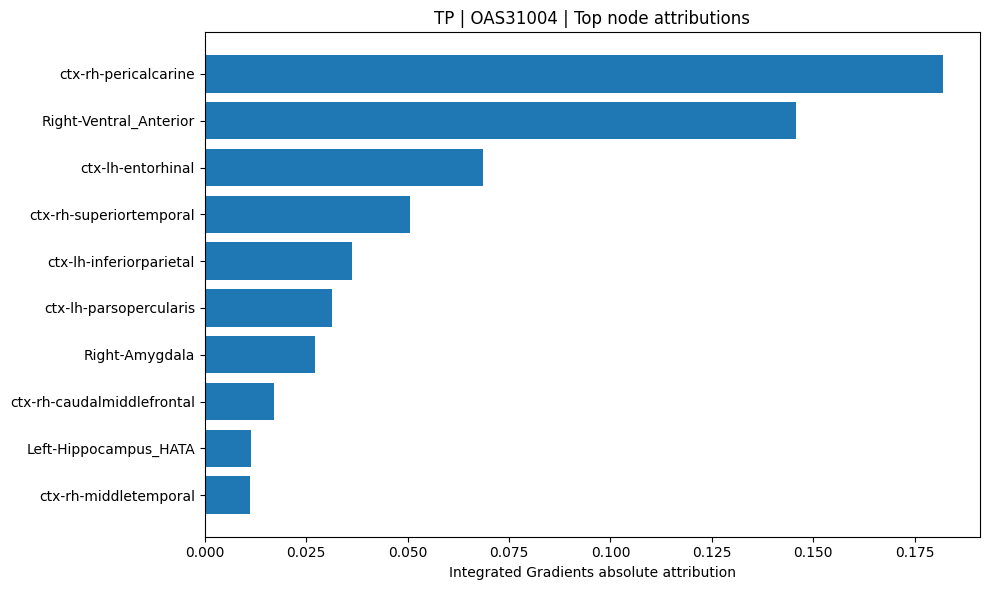

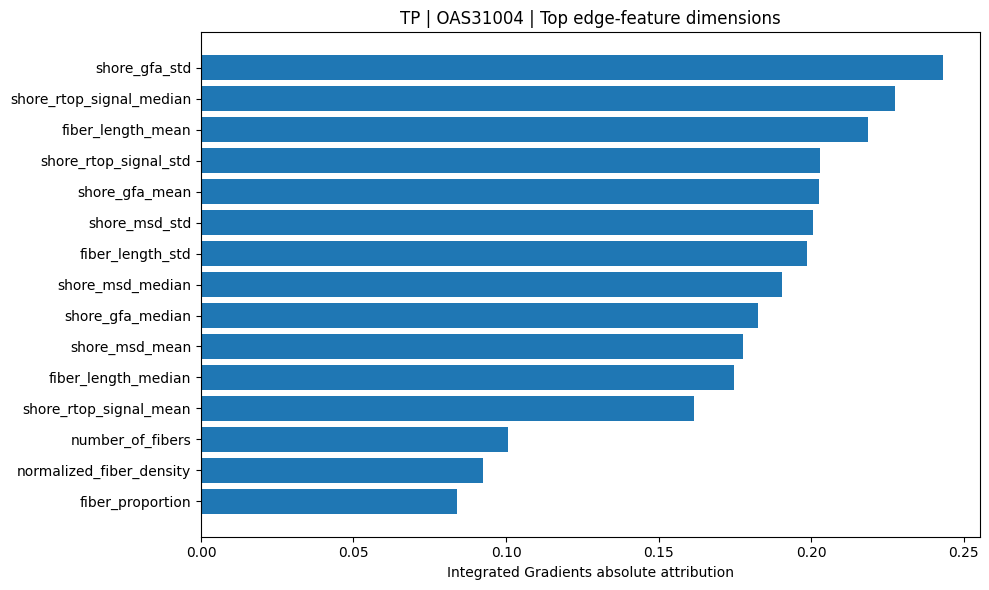

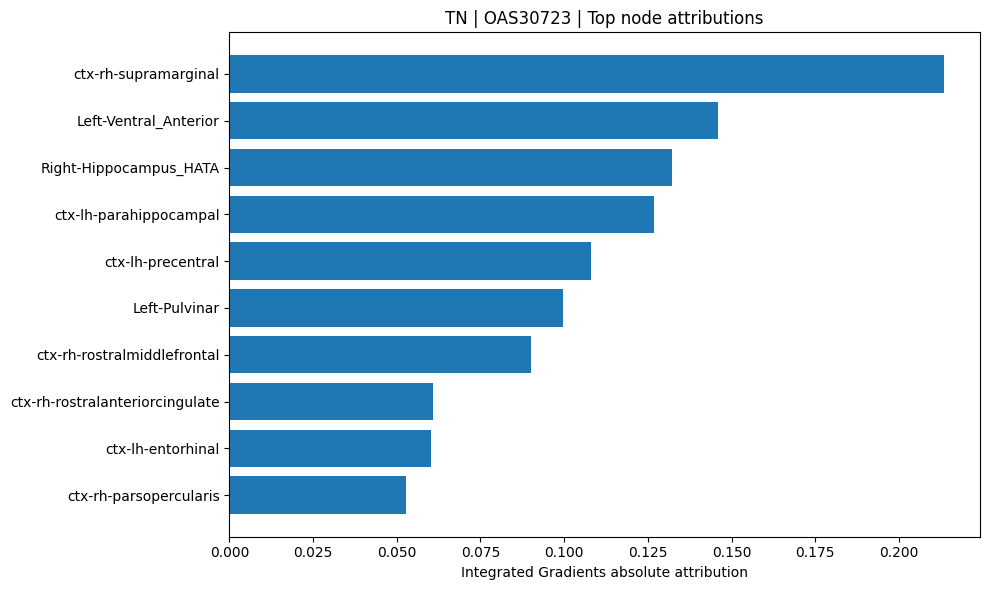

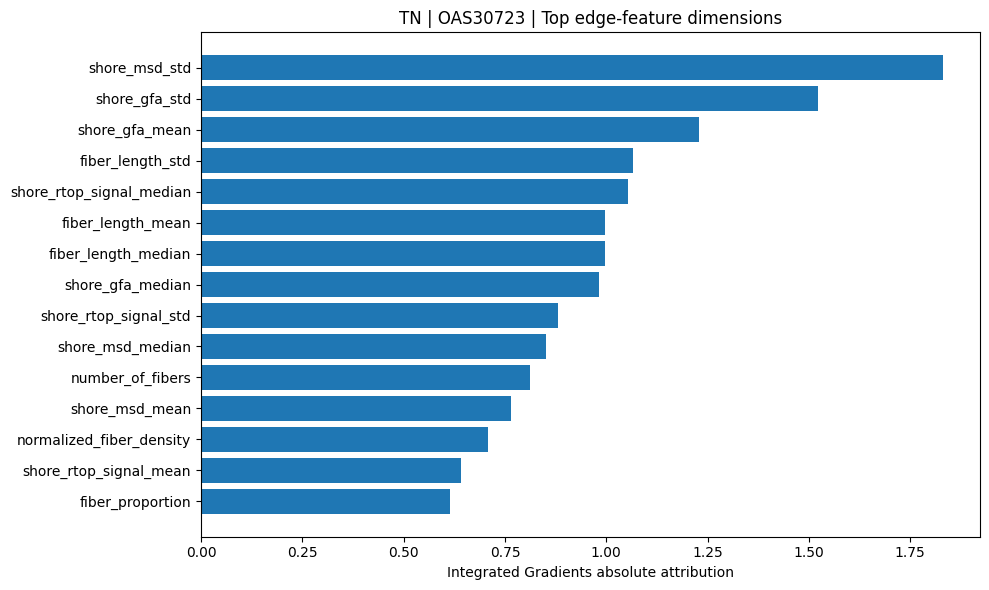

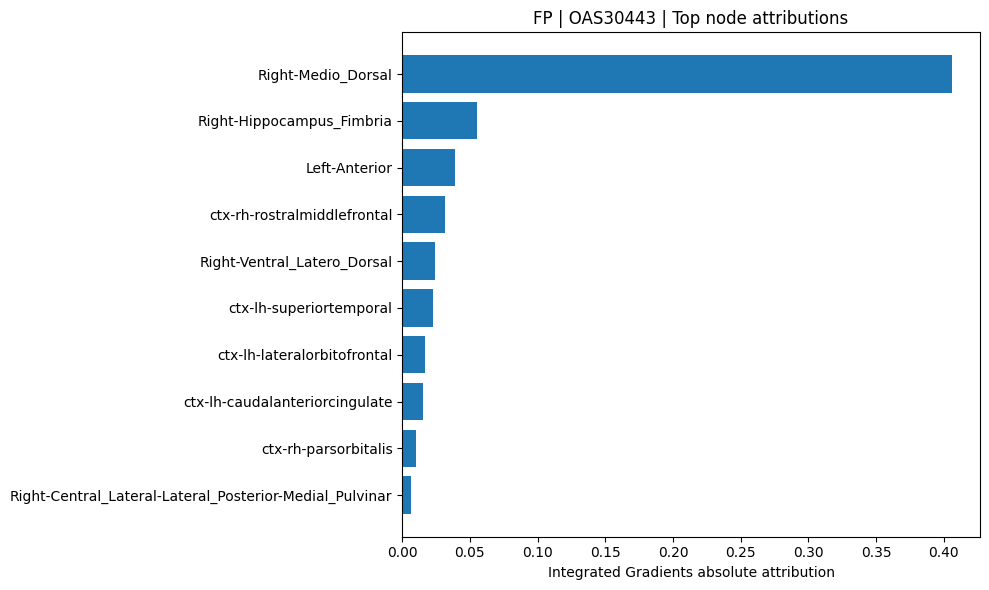

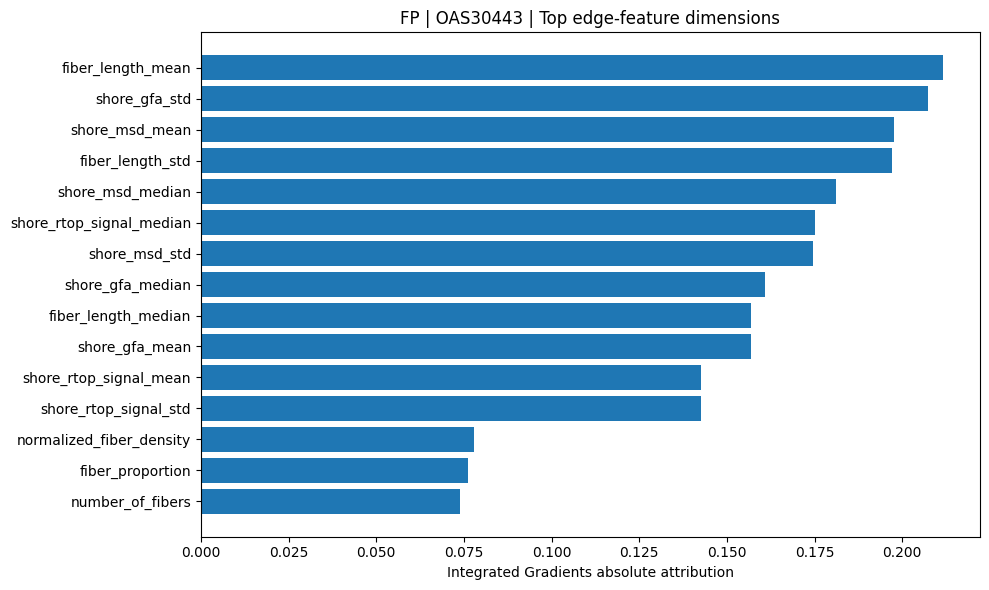

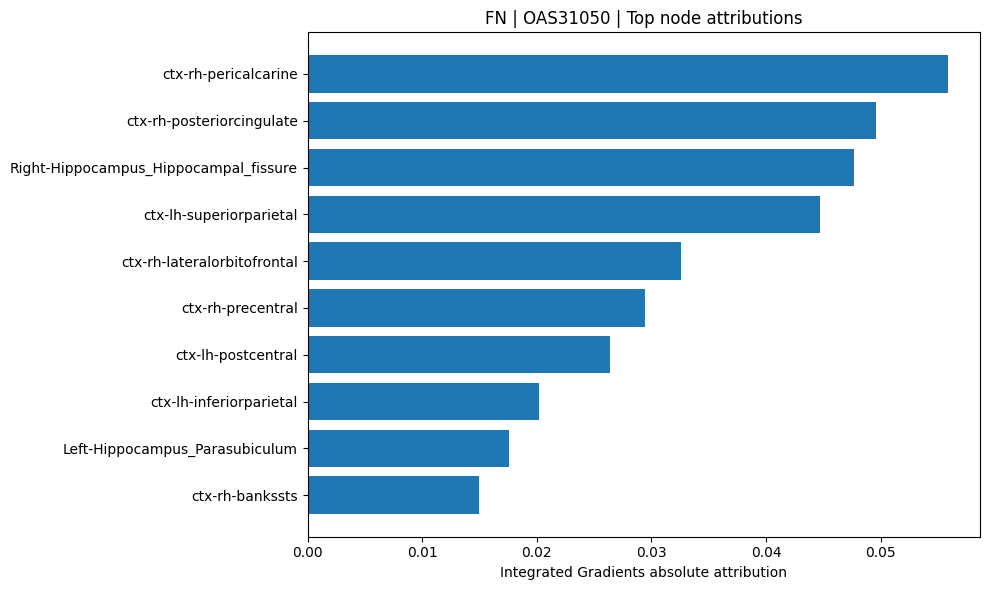

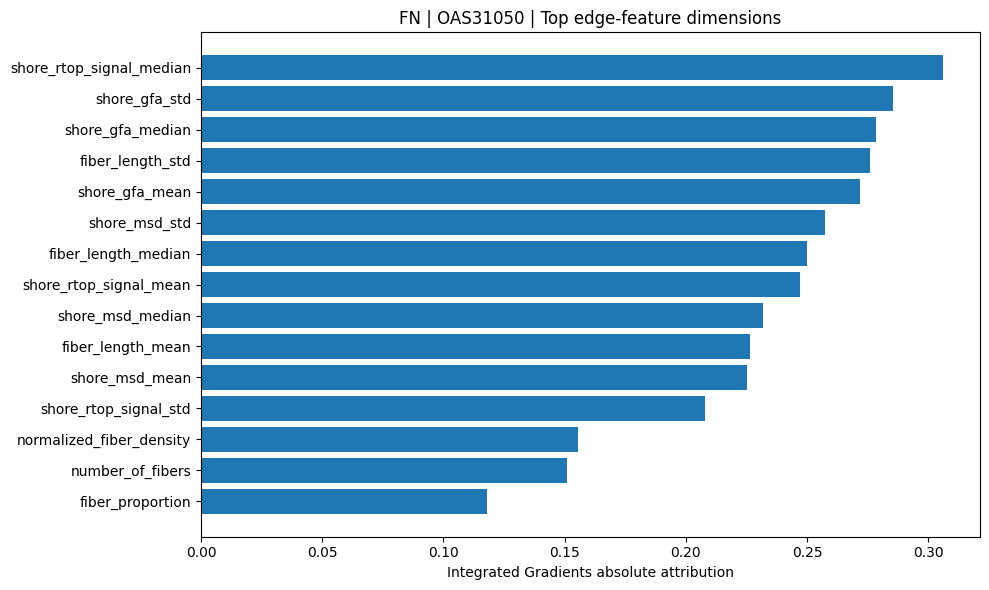

In [13]:

for tag, result in case_ig_results.items():
    subject_id = getattr(result['graph'], 'subject_id', 'unknown_subject')
    plot_top_ig_nodes(
        result['node_df'],
        title=f'{tag} | {subject_id} | Top node attributions',
        top_k=10,
    )
    plot_top_ig_edge_features(
        result['edge_feature_df'],
        title=f'{tag} | {subject_id} | Top edge-feature dimensions',
        top_k=15,
    )


### Integrated Gradients analysis averaged across all subjects per prediction outcome

In [14]:

def run_ig_population(result_pool, pred_label, tag, steps=50):
    '''
    Runs Integrated Gradients on every subject in one outcome group.
    The target class is fixed to the predicted class for that group.
    Returns mean node, node-feature, edge, and edge-feature importance scores.
    '''
    node_scores = []
    node_feature_scores = []
    node_feature_pair_scores = []
    edge_feature_scores = []
    total_attributions = []
    score_differences = []
    convergence_deltas = []

    for idx, (g, true, pred, prob_mci) in enumerate(result_pool):
        data = g.to(DEVICE)
        try:
            ig_result = run_integrated_gradients(data, steps=steps, target_class=pred_label)
            total_attr, score_diff, convergence_delta = summarize_ig_result(ig_result)

            node_scores.append(ig_result['node_importance'].detach().cpu().numpy())
            node_feature_scores.append(ig_result['node_feature_importance'].detach().cpu().numpy())
            # Matrix with shape [num_nodes, num_node_features]. This allows node ranking
            # for a specific feature such as volume or thickness.
            node_feature_pair_scores.append(ig_result['node_feature_pair_importance'].detach().cpu().numpy())
            edge_feature_scores.append(ig_result['edge_feature_importance'].detach().cpu().numpy())
            total_attributions.append(total_attr)
            score_differences.append(score_diff)
            convergence_deltas.append(convergence_delta)

        except Exception as e:
            subject_id = getattr(g, 'subject_id', f'{tag}_{idx}')
            print(f'{tag} | {subject_id}: Integrated Gradients failed: {e}')

    if len(node_scores) == 0:
        print(f'{tag}: no successful Integrated Gradients results.')
        return None

    mean_node_scores = np.stack(node_scores).mean(axis=0)
    mean_node_feature_scores = np.stack(node_feature_scores).mean(axis=0)
    mean_node_feature_pair_scores = np.stack(node_feature_pair_scores).mean(axis=0)
    mean_edge_feature_scores = np.stack(edge_feature_scores).mean(axis=0)

    print(f'{tag} (n={len(node_scores)}): population Integrated Gradients done.')
    return {
        'mean_node_scores': mean_node_scores,
        'mean_node_feature_scores': mean_node_feature_scores,
        'mean_node_feature_pair_scores': mean_node_feature_pair_scores,
        'mean_edge_feature_scores': mean_edge_feature_scores,
        'n': len(node_scores),
        'target_class': pred_label,
        'mean_total_signed_ig_attribution': float(np.mean(total_attributions)),
        'mean_score_difference': float(np.mean(score_differences)),
        'mean_convergence_delta': float(np.mean(convergence_deltas)),
    }


pop_ig_results = {}
for tag, pool, pred_l in [
    ('TP', TP, 1),
    ('TN', TN, 0),
    ('FP', FP, 1),
    ('FN', FN, 0),
]:
    if not pool:
        print(f'{tag}: no subjects, skipping.')
        continue
    result = run_ig_population(pool, pred_l, tag, steps=IG_STEPS)
    if result is not None:
        pop_ig_results[tag] = result


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


TP (n=14): population Integrated Gradients done.
TN (n=87): population Integrated Gradients done.
FP (n=18): population Integrated Gradients done.
FN (n=8): population Integrated Gradients done.


In [15]:

def top_population_nodes(mean_node_scores, top_n=10):
    top_idx = np.argsort(mean_node_scores)[::-1][:top_n]
    return pd.DataFrame({
        'rank': np.arange(1, len(top_idx) + 1),
        'node_index': top_idx,
        'region': [node_label(i) for i in top_idx],
        'mean_ig_node_score': mean_node_scores[top_idx],
    })


def top_population_node_features(mean_node_feature_scores):
    order = np.argsort(mean_node_feature_scores)[::-1]
    return pd.DataFrame({
        'rank': np.arange(1, len(order) + 1),
        'node_feature_index': order,
        'node_feature_name': [NODE_FEATURE_NAMES[i] if i < len(NODE_FEATURE_NAMES) else f'Node feature {i}' for i in order],
        'mean_ig_node_feature_score': mean_node_feature_scores[order],
    })


def top_population_edge_features(mean_edge_feature_scores):
    order = np.argsort(mean_edge_feature_scores)[::-1]
    return pd.DataFrame({
        'rank': np.arange(1, len(order) + 1),
        'edge_feature_index': order,
        'edge_feature_name': [edge_feature_label(i) for i in order],
        'mean_ig_edge_feature_score': mean_edge_feature_scores[order],
    })


population_node_tables = {}
population_node_feature_tables = {}
population_edge_feature_tables = {}
population_summary_rows = []

for tag, result in pop_ig_results.items():
    population_node_tables[tag] = top_population_nodes(result['mean_node_scores'], top_n=10)
    population_node_feature_tables[tag] = top_population_node_features(result['mean_node_feature_scores'])
    population_edge_feature_tables[tag] = top_population_edge_features(result['mean_edge_feature_scores'])

    top_node = population_node_tables[tag].iloc[0]
    top_edge_feature = population_edge_feature_tables[tag].iloc[0]

    population_summary_rows.append({
        'outcome': tag,
        'n_subjects': result['n'],
        'target_class': CLASS_NAMES[result['target_class']],
        'top_population_region': top_node['region'],
        'top_population_region_score': top_node['mean_ig_node_score'],
        'top_population_edge_feature': top_edge_feature['edge_feature_name'],
        'top_population_edge_feature_score': top_edge_feature['mean_ig_edge_feature_score'],
        'mean_score_difference': result['mean_score_difference'],
        'mean_total_signed_ig_attribution': result['mean_total_signed_ig_attribution'],
        'mean_convergence_delta': result['mean_convergence_delta'],
    })

population_ig_summary_df = pd.DataFrame(population_summary_rows)
display(population_ig_summary_df)

for tag in ['TP', 'TN', 'FP', 'FN']:
    if tag not in pop_ig_results:
        continue
    print(f'\n{tag}: population top ROIs')
    display(population_node_tables[tag])
    print(f'{tag}: population node-feature ranking')
    display(population_node_feature_tables[tag])
    print(f'{tag}: population edge-feature ranking')
    display(population_edge_feature_tables[tag])


,outcome,n_subjects,target_class,top_population_region,top_population_region_score,top_population_edge_feature,top_population_edge_feature_score,mean_score_difference,mean_total_signed_ig_attribution,mean_convergence_delta
0,TP,14,MCI,Left-Hippocampus_Fimbria,0.025258,shore_gfa_std,0.240821,-0.056121,-0.061899,0.005778
1,TN,87,CN,ctx-lh-parsorbitalis,0.019452,shore_gfa_std,0.445142,0.088913,0.093886,-0.004973
2,FP,18,MCI,Right-Medio_Dorsal,0.028692,shore_rtop_signal_std,0.259963,-0.111286,-0.084869,-0.026416
3,FN,8,CN,ctx-rh-superiortemporal,0.067148,shore_gfa_std,0.394060,0.036725,0.040511,-0.003786



TP: population top ROIs


,rank,node_index,region,mean_ig_node_score
0,1,108,Left-Hippocampus_Fimbria,0.025258
1,2,99,ctx-lh-parahippocampal,0.020725
2,3,17,ctx-lh-superiorfrontal,0.019605
3,4,36,ctx-rh-caudalmiddlefrontal,0.018384
4,5,106,Left-Hippocampus_HATA,0.017202
5,6,81,ctx-rh-pericalcarine,0.015922
6,7,78,ctx-lh-lingual,0.015632
7,8,32,Right-Hippocampus,0.013033
8,9,30,Right-Ventral_Anterior,0.012531
9,10,9,ctx-rh-frontalpole,0.012510


TP: population node-feature ranking


,rank,node_feature_index,node_feature_name,mean_ig_node_feature_score
0,1,0,volume,0.259092
1,2,3,has_thickness,0.191348
2,3,1,thickness,0.131602
3,4,2,has_volume,0.127592


...

,rank,node_index,region,mean_ig_node_score
0,1,28,ctx-rh-superiortemporal,0.067148
1,2,107,ctx-lh-entorhinal,0.047438
2,3,57,ctx-rh-bankssts,0.031100
3,4,39,Left-Accumbens_area,0.029578
4,5,102,ctx-lh-superiortemporal,0.028770
5,6,78,ctx-lh-lingual,0.021170
6,7,66,Right-Hippocampus_HATA,0.019455
7,8,86,ctx-lh-lateraloccipital,0.019305
8,9,43,Right-Central_Lateral-Lateral_Posterior-Medial...,0.019052
9,10,73,ctx-lh-inferiorparietal,0.018748


FN: population node-feature ranking


,rank,node_feature_index,node_feature_name,mean_ig_node_feature_score
0,1,3,has_thickness,0.382868
1,2,0,volume,0.360299
2,3,2,has_volume,0.264450
3,4,1,thickness,0.194537


FN: population edge-feature ranking


,rank,edge_feature_index,edge_feature_name,mean_ig_edge_feature_score
0,1,7,shore_gfa_std,0.394060
1,2,13,shore_rtop_signal_std,0.391479
2,3,3,fiber_length_std,0.347444
3,4,12,shore_rtop_signal_mean,0.335120
4,5,10,shore_msd_std,0.330043
5,6,14,shore_rtop_signal_median,0.319138
6,7,1,fiber_length_mean,0.318004
7,8,8,shore_gfa_median,0.309409
8,9,6,shore_gfa_mean,0.298861
9,10,9,shore_msd_mean,0.257906


### Node ranking by specific structural features

The global node ranking above sums the absolute Integrated Gradients attribution over all node features. To answer the question of which brain regions are important specifically because of **volume** or **thickness**, this section aggregates the node-feature attribution matrix across subjects inside each outcome group. This produces a separate ROI ranking for volume and a separate ROI ranking for thickness.


In [16]:

# Node ranking for specific node features, especially volume and thickness.
# This uses mean_node_feature_pair_scores with shape [num_nodes, num_node_features].

def get_node_feature_index(feature_name):
    matches = [i for i, name in enumerate(NODE_FEATURE_NAMES) if name == feature_name]
    if not matches:
        raise ValueError(f"{feature_name!r} was not found in NODE_FEATURE_NAMES: {NODE_FEATURE_NAMES}")
    return matches[0]


def top_population_nodes_for_feature(mean_node_feature_pair_scores, feature_name, top_n=15):
    feature_idx = get_node_feature_index(feature_name)
    scores = mean_node_feature_pair_scores[:, feature_idx]
    top_idx = np.argsort(scores)[::-1][:top_n]
    return pd.DataFrame({
        'rank': np.arange(1, len(top_idx) + 1),
        'node_index': top_idx,
        'region': [node_label(i) for i in top_idx],
        'node_feature_name': feature_name,
        'mean_abs_ig_score': scores[top_idx],
    })


node_feature_specific_tables = {}
node_feature_specific_summary_rows = []

for tag, result in pop_ig_results.items():
    if 'mean_node_feature_pair_scores' not in result:
        print(f'{tag}: mean_node_feature_pair_scores not available. Re-run the population IG cell above.')
        continue

    node_feature_specific_tables[tag] = {}

    for feature_name in ['volume', 'thickness']:
        table = top_population_nodes_for_feature(
            result['mean_node_feature_pair_scores'],
            feature_name=feature_name,
            top_n=15,
        )
        node_feature_specific_tables[tag][feature_name] = table

        if not table.empty:
            top_row = table.iloc[0]
            node_feature_specific_summary_rows.append({
                'outcome': tag,
                'n_subjects': result['n'],
                'target_class': CLASS_NAMES[result['target_class']],
                'node_feature_name': feature_name,
                'top_region': top_row['region'],
                'top_region_score': top_row['mean_abs_ig_score'],
            })

node_feature_specific_summary_df = pd.DataFrame(node_feature_specific_summary_rows)
display(node_feature_specific_summary_df)

for tag in ['TP', 'TN', 'FP', 'FN']:
    if tag not in node_feature_specific_tables:
        continue

    for feature_name in ['volume', 'thickness']:
        print(f'\n{tag}: top ROIs ranked by {feature_name} attribution')
        display(node_feature_specific_tables[tag][feature_name])


,outcome,n_subjects,target_class,node_feature_name,top_region,top_region_score
0,TP,14,MCI,volume,Left-Hippocampus_Fimbria,0.014441
1,TP,14,MCI,thickness,ctx-rh-caudalmiddlefrontal,0.007043
2,TN,87,CN,volume,ctx-lh-parsorbitalis,0.009286
3,TN,87,CN,thickness,ctx-rh-lateralorbitofrontal,0.008024
4,FP,18,MCI,volume,Right-Medio_Dorsal,0.021658
5,FP,18,MCI,thickness,ctx-rh-lateralorbitofrontal,0.003925
6,FN,8,CN,volume,ctx-rh-superiortemporal,0.032800
7,FN,8,CN,thickness,ctx-rh-superiortemporal,0.014086



TP: top ROIs ranked by volume attribution


,rank,node_index,region,node_feature_name,mean_abs_ig_score
0,1,108,Left-Hippocampus_Fimbria,volume,0.014441
1,2,99,ctx-lh-parahippocampal,volume,0.010217
2,3,9,ctx-rh-frontalpole,volume,0.010045
3,4,17,ctx-lh-superiorfrontal,volume,0.008631
4,5,3,Right-Caudate,volume,0.008617
5,6,81,ctx-rh-pericalcarine,volume,0.008529
6,7,36,ctx-rh-caudalmiddlefrontal,volume,0.008176
7,8,30,Right-Ventral_Anterior,volume,0.007610
8,9,106,Left-Hippocampus_HATA,volume,0.007544
9,10,32,Right-Hippocampus,volume,0.006973



TP: top ROIs ranked by thickness attribution


,rank,node_index,region,node_feature_name,mean_abs_ig_score
0,1,36,ctx-rh-caudalmiddlefrontal,thickness,0.007043
1,2,17,ctx-lh-superiorfrontal,thickness,0.006370
2,3,99,ctx-lh-parahippocampal,thickness,0.005392
3,4,108,Left-Hippocampus_Fimbria,thickness,0.004906
4,5,78,ctx-lh-lingual,thickness,0.004044
5,6,81,ctx-rh-pericalcarine,thickness,0.003932
6,7,106,Left-Hippocampus_HATA,thickness,0.003619
7,8,90,Right-Hippocampus_Tail,thickness,0.003533
8,9,33,Right-Amygdala,thickness,0.003354
9,10,107,ctx-lh-entorhinal,thickness,0.002936


...

,rank,node_index,region,node_feature_name,mean_abs_ig_score
0,1,0,ctx-rh-lateralorbitofrontal,thickness,0.003925
1,2,10,ctx-rh-insula,thickness,0.003428
2,3,34,Right-VentralDC,thickness,0.003182
3,4,99,ctx-lh-parahippocampal,thickness,0.002965
4,5,96,Right-Hippocampus_Parasubiculum,thickness,0.002690
5,6,20,ctx-rh-fusiform,thickness,0.002666
6,7,13,ctx-rh-caudalanteriorcingulate,thickness,0.002617
7,8,31,Right-Medio_Dorsal,thickness,0.002511
8,9,89,Right-Hippocampus_Hippocampal_fissure,thickness,0.002336
9,10,86,ctx-lh-lateraloccipital,thickness,0.002259



FN: top ROIs ranked by volume attribution


,rank,node_index,region,node_feature_name,mean_abs_ig_score
0,1,28,ctx-rh-superiortemporal,volume,0.032800
1,2,107,ctx-lh-entorhinal,volume,0.027428
2,3,39,Left-Accumbens_area,volume,0.018714
3,4,102,ctx-lh-superiortemporal,volume,0.011811
4,5,83,Left-Hippocampus,volume,0.011483
5,6,73,ctx-lh-inferiorparietal,volume,0.009609
6,7,24,ctx-rh-posteriorcingulate,volume,0.009097
7,8,86,ctx-lh-lateraloccipital,volume,0.009034
8,9,10,ctx-rh-insula,volume,0.008606
9,10,29,Left-Caudate,volume,0.007578



FN: top ROIs ranked by thickness attribution


,rank,node_index,region,node_feature_name,mean_abs_ig_score
0,1,28,ctx-rh-superiortemporal,thickness,0.014086
1,2,57,ctx-rh-bankssts,thickness,0.010942
2,3,4,Right-Accumbens_area,thickness,0.007668
3,4,78,ctx-lh-lingual,thickness,0.007247
4,5,51,ctx-lh-precentral,thickness,0.006595
5,6,0,ctx-rh-lateralorbitofrontal,thickness,0.006584
6,7,107,ctx-lh-entorhinal,thickness,0.006261
7,8,106,Left-Hippocampus_HATA,thickness,0.005974
8,9,37,ctx-rh-middletemporal,thickness,0.004915
9,10,7,ctx-rh-parsorbitalis,thickness,0.004807


### Visualizing volume- and thickness-specific ROI rankings

These plots show the top ROIs for each outcome group after aggregating Integrated Gradients only over the selected node feature. They make the result easier to discuss than the tables alone.


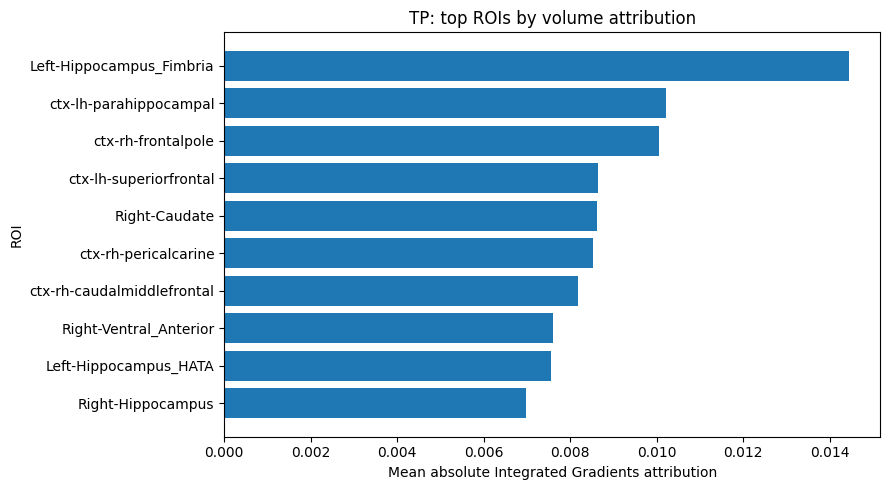

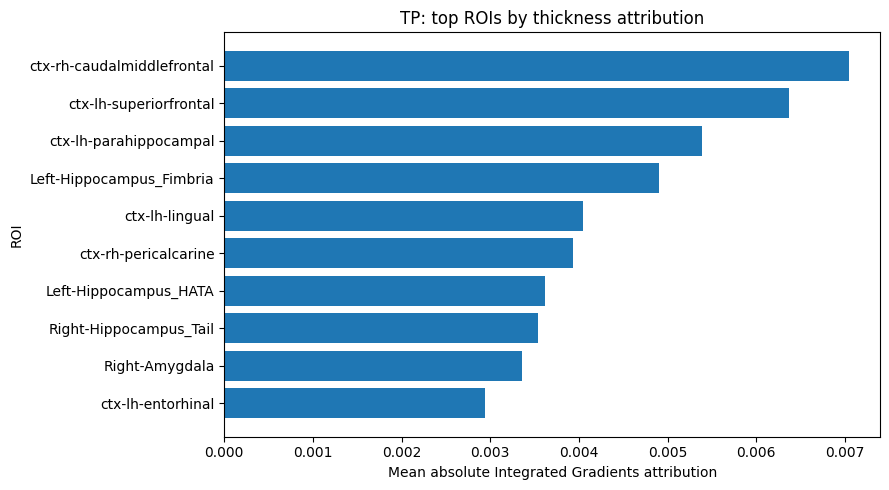

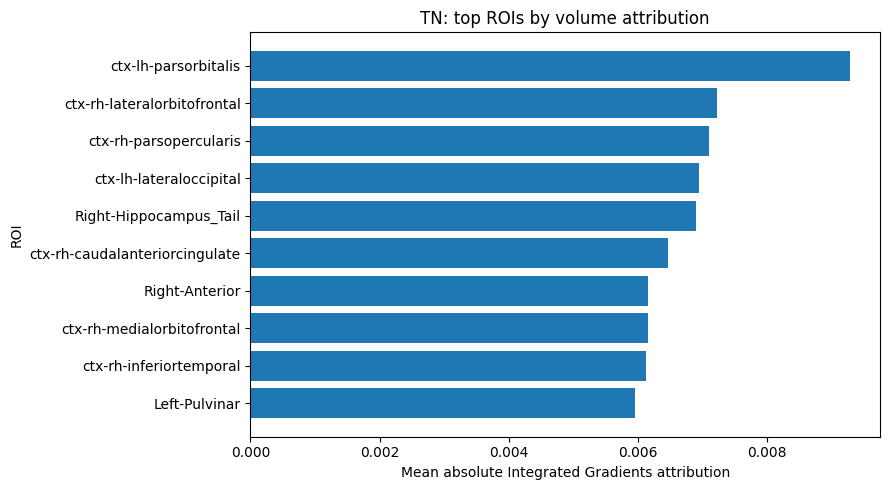

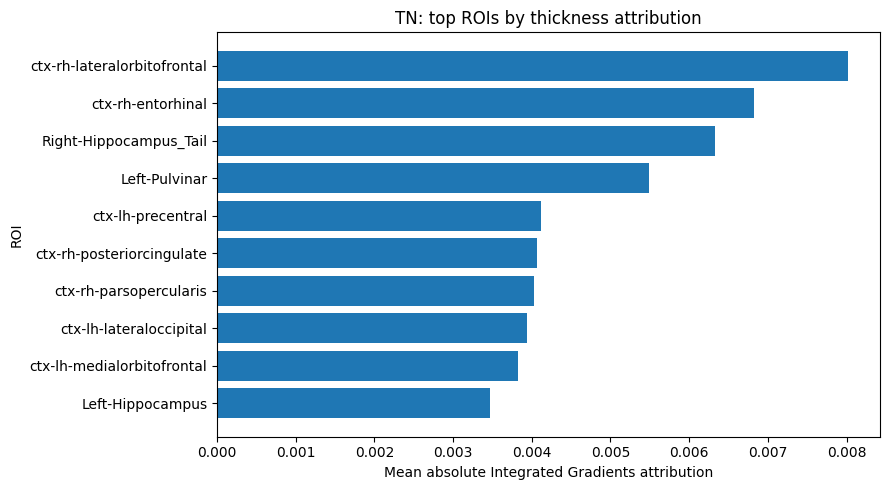

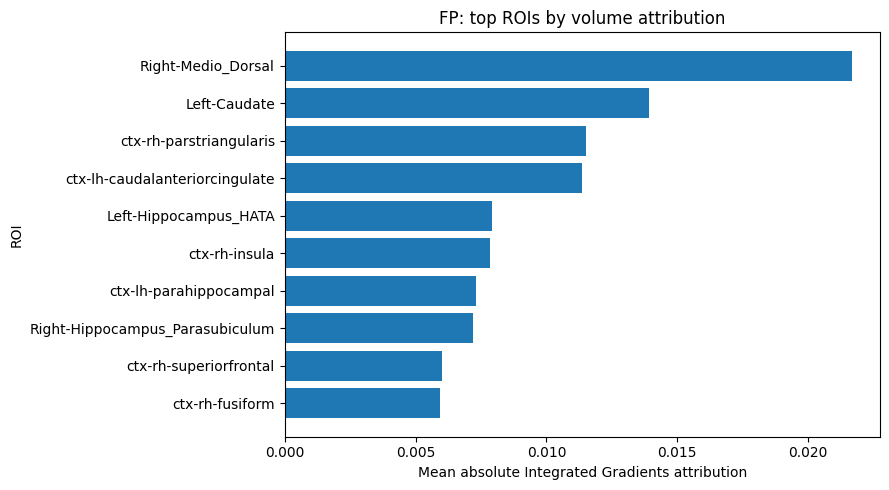

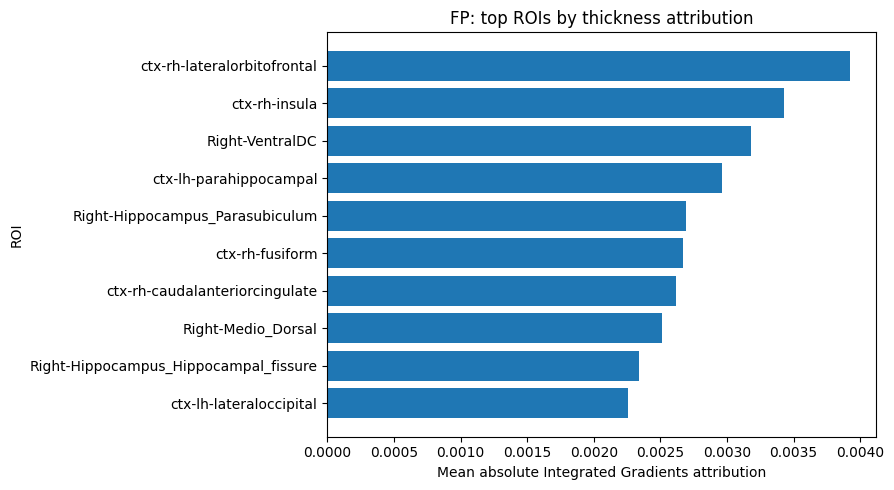

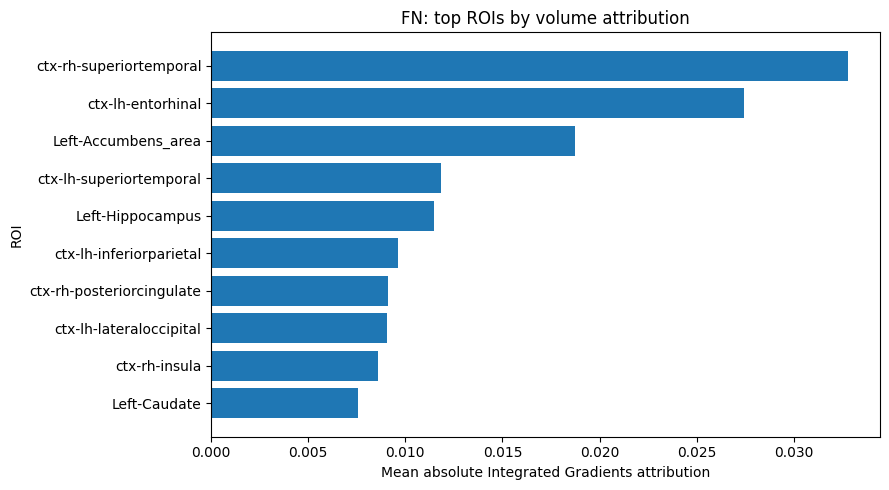

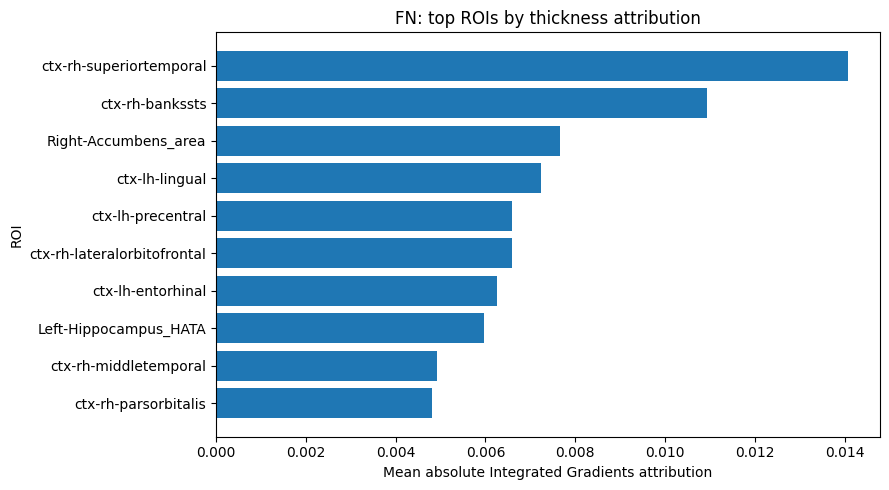

In [17]:

def plot_node_feature_specific_ranking(table, title, top_n=10):
    if table is None or table.empty:
        print(f'No data available for {title}')
        return

    plot_df = table.head(top_n).iloc[::-1]
    plt.figure(figsize=(9, 5))
    plt.barh(plot_df['region'], plot_df['mean_abs_ig_score'])
    plt.xlabel('Mean absolute Integrated Gradients attribution')
    plt.ylabel('ROI')
    plt.title(title)
    plt.tight_layout()
    plt.show()


for tag in ['TP', 'TN', 'FP', 'FN']:
    if tag not in node_feature_specific_tables:
        continue

    for feature_name in ['volume', 'thickness']:
        plot_node_feature_specific_ranking(
            node_feature_specific_tables[tag][feature_name],
            title=f'{tag}: top ROIs by {feature_name} attribution',
            top_n=10,
        )


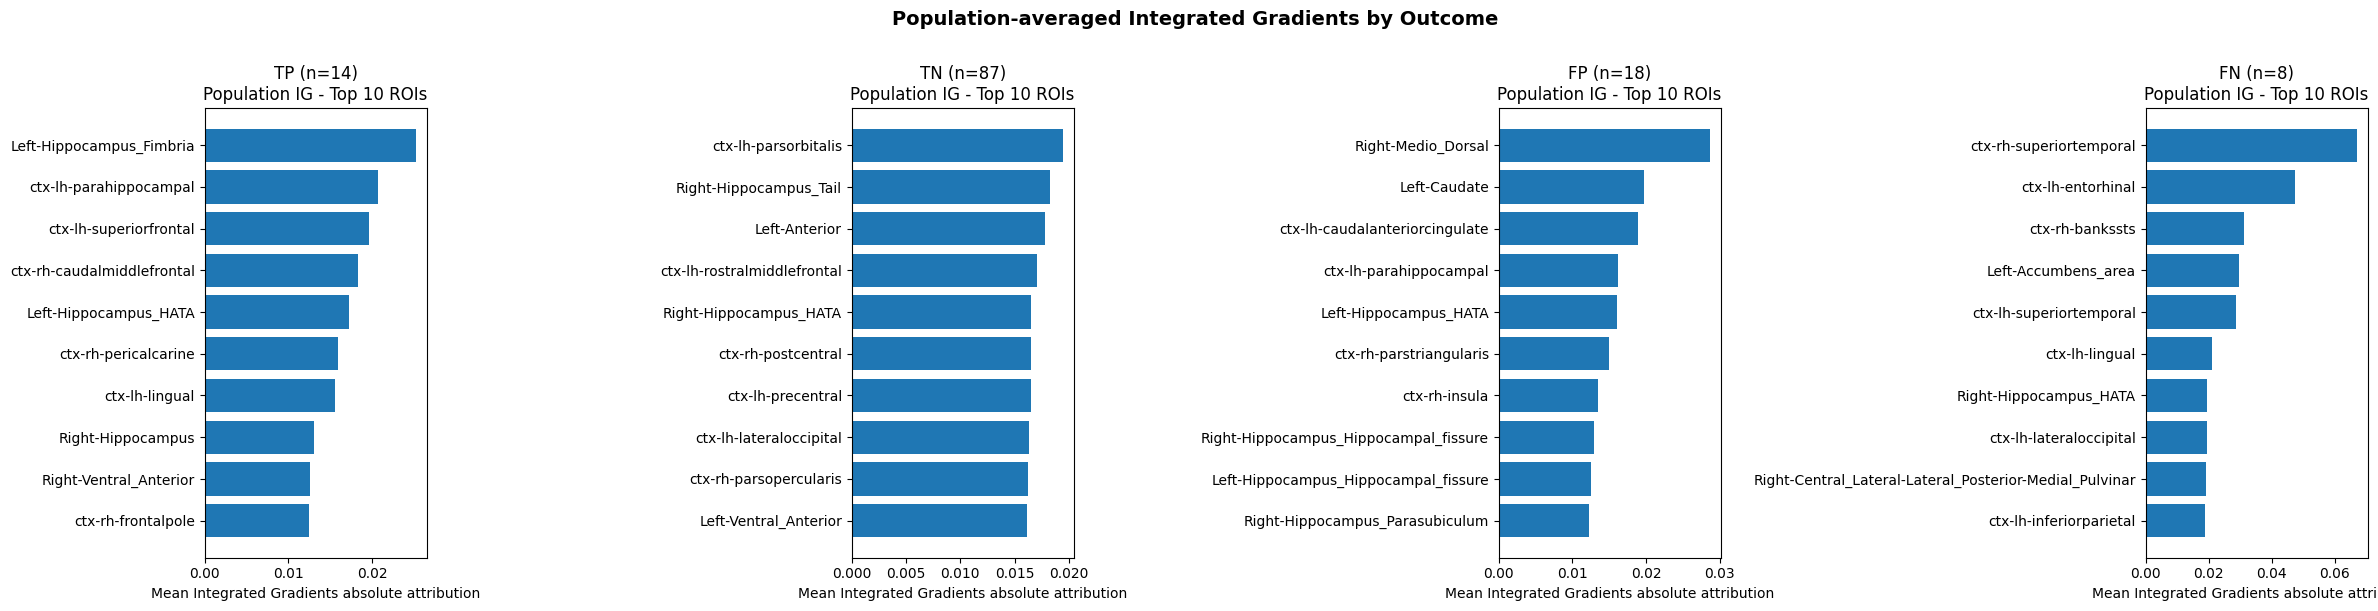

In [18]:

# Population-level top ROIs for all available outcome groups.
available_tags = [t for t in ['TP', 'TN', 'FP', 'FN'] if t in pop_ig_results]

if available_tags:
    fig, axes = plt.subplots(1, len(available_tags), figsize=(6 * len(available_tags), 6))
    if len(available_tags) == 1:
        axes = [axes]

    for ax, tag in zip(axes, available_tags):
        table = population_node_tables[tag].head(10).iloc[::-1]
        ax.barh(table['region'], table['mean_ig_node_score'])
        ax.set_xlabel('Mean Integrated Gradients absolute attribution')
        ax.set_title(f'{tag} (n={pop_ig_results[tag]["n"]})\nPopulation IG - Top 10 ROIs')

    plt.suptitle('Population-averaged Integrated Gradients by Outcome', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


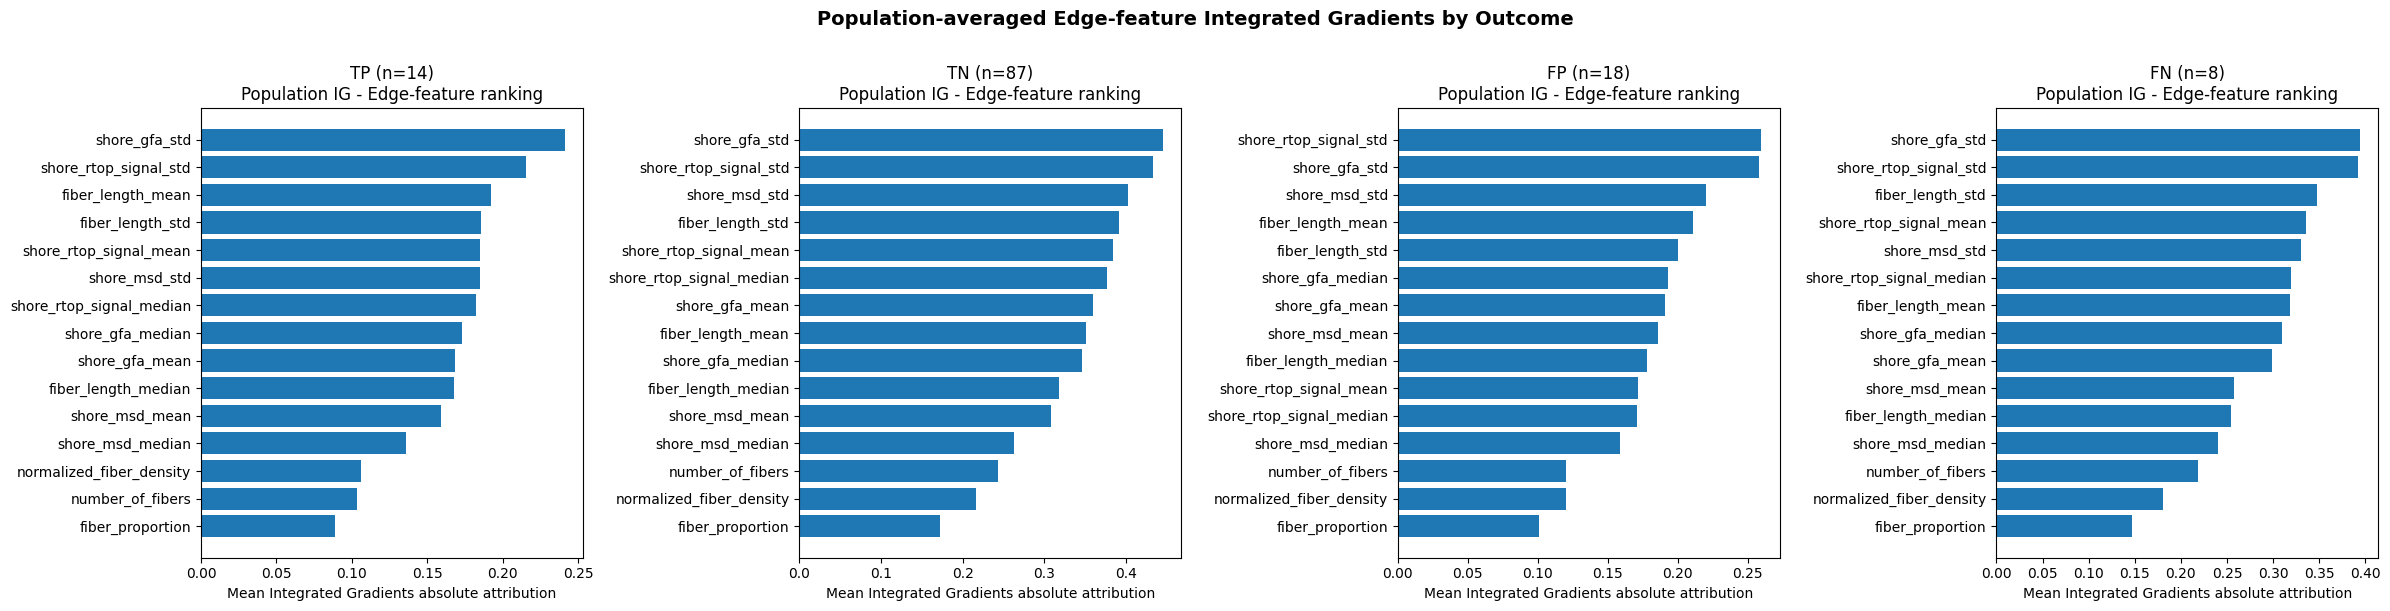

In [19]:

# Population-level edge-feature rankings for all available outcome groups.
if available_tags:
    fig, axes = plt.subplots(1, len(available_tags), figsize=(6 * len(available_tags), 6))
    if len(available_tags) == 1:
        axes = [axes]

    for ax, tag in zip(axes, available_tags):
        table = population_edge_feature_tables[tag].head(15).iloc[::-1]
        ax.barh(table['edge_feature_name'], table['mean_ig_edge_feature_score'])
        ax.set_xlabel('Mean Integrated Gradients absolute attribution')
        ax.set_title(f'{tag} (n={pop_ig_results[tag]["n"]})\nPopulation IG - Edge-feature ranking')

    plt.suptitle('Population-averaged Edge-feature Integrated Gradients by Outcome', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


### Final interpretation tables

In [20]:

print('Prediction outcome counts:')
display(predictions_df['outcome'].value_counts(dropna=False).rename_axis('outcome').reset_index(name='count'))

print('Most confident subject Integrated Gradients summary:')
display(case_ig_summary_df)

print('Population Integrated Gradients summary by outcome:')
display(population_ig_summary_df)

for tag in ['TP', 'TN', 'FP', 'FN']:
    if tag in case_ig_results:
        print(f'\n{tag}: most confident subject top nodes')
        display(case_ig_results[tag]['node_df'])
        print(f'{tag}: most confident subject top edge-feature pairs')
        display(case_ig_results[tag]['edge_feature_pair_df'])

for tag in ['TP', 'TN', 'FP', 'FN']:
    if tag in population_node_tables:
        print(f'\n{tag}: population top nodes')
        display(population_node_tables[tag])
        print(f'{tag}: population edge-feature ranking')
        display(population_edge_feature_tables[tag])


Prediction outcome counts:


,outcome,count
0,TN,87
1,FP,18
2,TP,14
3,FN,8


Most confident subject Integrated Gradients summary:


,outcome,subject_id,true_label,pred_label,prob_MCI,target_class,baseline_score,target_score,score_difference,total_signed_ig_attribution,approx_convergence_delta,top_region,top_region_score,top_edge_feature,top_edge_feature_score
0,TP,OAS31004,MCI,MCI,0.697168,MCI,0.003625,0.215431,0.211807,0.334920,-0.123114,ctx-rh-pericalcarine,0.181992,shore_gfa_std,0.243230
1,TN,OAS30723,CN,CN,0.279208,CN,0.015546,-0.074178,-0.089724,-0.425329,0.335605,ctx-rh-supramarginal,0.213508,shore_msd_std,1.830444
2,FP,OAS30443,CN,MCI,0.788773,MCI,0.002803,0.387851,0.385048,0.387408,-0.002360,Right-Medio_Dorsal,0.406365,fiber_length_mean,0.211579
3,FN,OAS31050,MCI,CN,0.366221,CN,0.016548,0.277566,0.261019,0.320973,-0.059954,ctx-rh-pericalcarine,0.055888,shore_rtop_signal_median,0.306059


Population Integrated Gradients summary by outcome:


...

,rank,edge_feature_index,edge_feature_name,mean_ig_edge_feature_score
0,1,13,shore_rtop_signal_std,0.259963
1,2,7,shore_gfa_std,0.258483
2,3,10,shore_msd_std,0.220101
3,4,1,fiber_length_mean,0.211156
4,5,3,fiber_length_std,0.200231
5,6,8,shore_gfa_median,0.192769
6,7,6,shore_gfa_mean,0.191204
7,8,9,shore_msd_mean,0.185776
8,9,2,fiber_length_median,0.177786
9,10,12,shore_rtop_signal_mean,0.171477



FN: population top nodes


,rank,node_index,region,mean_ig_node_score
0,1,28,ctx-rh-superiortemporal,0.067148
1,2,107,ctx-lh-entorhinal,0.047438
2,3,57,ctx-rh-bankssts,0.031100
3,4,39,Left-Accumbens_area,0.029578
4,5,102,ctx-lh-superiortemporal,0.028770
5,6,78,ctx-lh-lingual,0.021170
6,7,66,Right-Hippocampus_HATA,0.019455
7,8,86,ctx-lh-lateraloccipital,0.019305
8,9,43,Right-Central_Lateral-Lateral_Posterior-Medial...,0.019052
9,10,73,ctx-lh-inferiorparietal,0.018748


FN: population edge-feature ranking


,rank,edge_feature_index,edge_feature_name,mean_ig_edge_feature_score
0,1,7,shore_gfa_std,0.394060
1,2,13,shore_rtop_signal_std,0.391479
2,3,3,fiber_length_std,0.347444
3,4,12,shore_rtop_signal_mean,0.335120
4,5,10,shore_msd_std,0.330043
5,6,14,shore_rtop_signal_median,0.319138
6,7,1,fiber_length_mean,0.318004
7,8,8,shore_gfa_median,0.309409
8,9,6,shore_gfa_mean,0.298861
9,10,9,shore_msd_mean,0.257906


### Interpretation note

Integrated Gradients attributes the NNConv prediction to the input values along a path from a **global training-set mean baseline** to the observed graph. The mean baseline represents an average training subject, so the attribution values describe how each subject deviates from a typical training graph. This is preferable to an all-zero baseline because zero-valued morphometric and dMRI connectivity features do not correspond to a realistic brain graph.

High absolute attribution means that the node feature, edge, or edge-feature dimension had a strong contribution to the selected output logit. The most confident TP, TN, FP, and FN subjects provide individual case studies, while the population-averaged tables summarize the common attribution patterns within each outcome group.


The volume- and thickness-specific node rankings aggregate the absolute IG values for one node-feature column at a time. Therefore, they answer a more targeted question than the overall ROI ranking: not just which regions were important overall, but which regions were important specifically through volume or thickness relative to the training-set mean baseline.

###Per class results

In [21]:
# Per-class Integrated Gradients analysis using TRUE LABELS


# Since TP/TN/FP/FN outcome analysis has already been done,
# this per-class analysis uses the actual diagnostic class.
CLASS_GROUP_COL = 'true_label'

class_ig_results = {}
class_ig_pools = {}

for class_id, class_name in CLASS_NAMES.items():
    class_df = predictions_df[predictions_df[CLASS_GROUP_COL] == class_id].copy()

    if class_df.empty:
        print(f'{class_name}: no subjects for {CLASS_GROUP_COL}, skipping.')
        continue

    # Convert dataframe rows into the same tuple format used by run_ig_population:
    # (graph, true_label, pred_label, prob_MCI)
    pool = []

    for _, row in class_df.iterrows():
        test_idx = int(row['test_index'])
        g = test_graphs[test_idx]
        true = int(row['true_label'])
        pred = int(row['pred_label'])
        prob_mci = float(row['prob_MCI'])

        pool.append((g, true, pred, prob_mci))

    class_ig_pools[class_name] = pool

    print(f'Running true-label per-class IG for actual {class_name}: n={len(pool)}')

    # Because this is TRUE-label per-class analysis,
    # the IG target class is the actual class: CN target for true CN, MCI target for true MCI.
    result = run_ig_population(
        result_pool=pool,
        pred_label=class_id,
        tag=f'True_{class_name}',
        steps=IG_STEPS,
    )

    if result is not None:
        class_ig_results[class_name] = result


print('True-label per-class Integrated Gradients complete.')
print('Available class groups:', list(class_ig_results.keys()))

Running true-label per-class IG for actual CN: n=105


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


True_CN (n=105): population Integrated Gradients done.
Running true-label per-class IG for actual MCI: n=22
True_MCI (n=22): population Integrated Gradients done.
True-label per-class Integrated Gradients complete.
Available class groups: ['CN', 'MCI']


In [22]:

# Per-class Integrated Gradients summary tables


class_population_node_tables = {}
class_population_node_feature_tables = {}
class_population_edge_feature_tables = {}
class_population_summary_rows = []

for class_name, result in class_ig_results.items():
    class_population_node_tables[class_name] = top_population_nodes(
        result['mean_node_scores'],
        top_n=15,
    )

    class_population_node_feature_tables[class_name] = top_population_node_features(
        result['mean_node_feature_scores'],
    )

    class_population_edge_feature_tables[class_name] = top_population_edge_features(
        result['mean_edge_feature_scores'],
    )

    top_node = class_population_node_tables[class_name].iloc[0]
    top_edge_feature = class_population_edge_feature_tables[class_name].iloc[0]

    class_population_summary_rows.append({
        'class_grouping': 'true_label',
        'actual_class': class_name,
        'n_subjects': result['n'],
        'target_class': CLASS_NAMES[result['target_class']],
        'top_population_region': top_node['region'],
        'top_population_region_score': top_node['mean_ig_node_score'],
        'top_population_edge_feature': top_edge_feature['edge_feature_name'],
        'top_population_edge_feature_score': top_edge_feature['mean_ig_edge_feature_score'],
        'mean_score_difference': result['mean_score_difference'],
        'mean_total_signed_ig_attribution': result['mean_total_signed_ig_attribution'],
        'mean_convergence_delta': result['mean_convergence_delta'],
    })


class_population_ig_summary_df = pd.DataFrame(class_population_summary_rows)

print('True-label per-class Integrated Gradients summary:')
display(class_population_ig_summary_df)


for class_name in ['CN', 'MCI']:
    if class_name not in class_ig_results:
        continue

    print(f'\nActual {class_name}: population top ROIs')
    display(class_population_node_tables[class_name])

    print(f'Actual {class_name}: population node-feature ranking')
    display(class_population_node_feature_tables[class_name])

    print(f'Actual {class_name}: population edge-feature ranking')
    display(class_population_edge_feature_tables[class_name])

True-label per-class Integrated Gradients summary:


,class_grouping,actual_class,n_subjects,target_class,top_population_region,top_population_region_score,top_population_edge_feature,top_population_edge_feature_score,mean_score_difference,mean_total_signed_ig_attribution,mean_convergence_delta
0,true_label,CN,105,CN,Right-Medio_Dorsal,0.020920,shore_gfa_std,0.449232,0.007557,0.009217,-0.001660
1,true_label,MCI,22,MCI,Left-Hippocampus_Fimbria,0.016699,shore_gfa_std,0.241133,-0.134771,-0.140627,0.005856



Actual CN: population top ROIs


,rank,node_index,region,mean_ig_node_score
0,1,31,Right-Medio_Dorsal,0.020920
1,2,35,ctx-lh-parsorbitalis,0.018495
2,3,106,Left-Hippocampus_HATA,0.018279
3,4,54,Left-Anterior,0.018118
4,5,66,Right-Hippocampus_HATA,0.016897
5,6,90,Right-Hippocampus_Tail,0.016581
6,7,51,ctx-lh-precentral,0.016571
7,8,15,ctx-rh-parsopercularis,0.016355
8,9,99,ctx-lh-parahippocampal,0.016266
9,10,45,ctx-lh-rostralmiddlefrontal,0.016131


Actual CN: population node-feature ranking


...

,rank,node_index,region,mean_ig_node_score
0,1,108,Left-Hippocampus_Fimbria,0.016699
1,2,99,ctx-lh-parahippocampal,0.014245
2,3,17,ctx-lh-superiorfrontal,0.013878
3,4,78,ctx-lh-lingual,0.013838
4,5,106,Left-Hippocampus_HATA,0.013808
5,6,36,ctx-rh-caudalmiddlefrontal,0.013362
6,7,81,ctx-rh-pericalcarine,0.012939
7,8,28,ctx-rh-superiortemporal,0.011904
8,9,73,ctx-lh-inferiorparietal,0.011143
9,10,107,ctx-lh-entorhinal,0.010913


Actual MCI: population node-feature ranking


,rank,node_feature_index,node_feature_name,mean_ig_node_feature_score
0,1,0,volume,0.234851
1,2,3,has_thickness,0.180787
2,3,2,has_volume,0.127307
3,4,1,thickness,0.117219


Actual MCI: population edge-feature ranking


,rank,edge_feature_index,edge_feature_name,mean_ig_edge_feature_score
0,1,7,shore_gfa_std,0.241133
1,2,13,shore_rtop_signal_std,0.218506
2,3,10,shore_msd_std,0.190556
3,4,1,fiber_length_mean,0.186362
4,5,3,fiber_length_std,0.181566
5,6,12,shore_rtop_signal_mean,0.181116
6,7,14,shore_rtop_signal_median,0.181041
7,8,8,shore_gfa_median,0.176402
8,9,6,shore_gfa_mean,0.173332
9,10,2,fiber_length_median,0.161019


In [23]:
# ============================================================
# Per-class ROI rankings for volume and thickness
# Append after Cell 2
# ============================================================

class_node_feature_specific_tables = {}
class_node_feature_specific_summary_rows = []

for class_name, result in class_ig_results.items():
    if 'mean_node_feature_pair_scores' not in result:
        print(f'{class_name}: mean_node_feature_pair_scores not available.')
        continue

    class_node_feature_specific_tables[class_name] = {}

    for feature_name in ['volume', 'thickness']:
        table = top_population_nodes_for_feature(
            result['mean_node_feature_pair_scores'],
            feature_name=feature_name,
            top_n=15,
        )

        class_node_feature_specific_tables[class_name][feature_name] = table

        if not table.empty:
            top_row = table.iloc[0]

            class_node_feature_specific_summary_rows.append({
                'class_grouping': 'true_label',
                'actual_class': class_name,
                'n_subjects': result['n'],
                'target_class': CLASS_NAMES[result['target_class']],
                'node_feature_name': feature_name,
                'top_region': top_row['region'],
                'top_region_score': top_row['mean_abs_ig_score'],
            })


class_node_feature_specific_summary_df = pd.DataFrame(
    class_node_feature_specific_summary_rows
)

print('True-label per-class volume/thickness ROI summary:')
display(class_node_feature_specific_summary_df)


for class_name in ['CN', 'MCI']:
    if class_name not in class_node_feature_specific_tables:
        continue

    for feature_name in ['volume', 'thickness']:
        print(f'\nActual {class_name}: top ROIs ranked by {feature_name} attribution')
        display(class_node_feature_specific_tables[class_name][feature_name])

True-label per-class volume/thickness ROI summary:


,class_grouping,actual_class,n_subjects,target_class,node_feature_name,top_region,top_region_score
0,true_label,CN,105,CN,volume,Right-Medio_Dorsal,0.011608
1,true_label,CN,105,CN,thickness,ctx-rh-lateralorbitofrontal,0.008051
2,true_label,MCI,22,MCI,volume,Left-Hippocampus_Fimbria,0.009260
3,true_label,MCI,22,MCI,thickness,ctx-rh-caudalmiddlefrontal,0.004608



Actual CN: top ROIs ranked by volume attribution


,rank,node_index,region,node_feature_name,mean_abs_ig_score
0,1,31,Right-Medio_Dorsal,volume,0.011608
1,2,35,ctx-lh-parsorbitalis,volume,0.008595
2,3,106,Left-Hippocampus_HATA,volume,0.007572
3,4,15,ctx-rh-parsopercularis,volume,0.007219
4,5,0,ctx-rh-lateralorbitofrontal,volume,0.007183
5,6,18,ctx-lh-caudalanteriorcingulate,volume,0.007098
6,7,8,Right-Anterior,volume,0.006754
7,8,10,ctx-rh-insula,volume,0.006724
8,9,2,ctx-rh-medialorbitofrontal,volume,0.006339
9,10,86,ctx-lh-lateraloccipital,volume,0.006335



Actual CN: top ROIs ranked by thickness attribution


,rank,node_index,region,node_feature_name,mean_abs_ig_score
0,1,0,ctx-rh-lateralorbitofrontal,thickness,0.008051
1,2,98,ctx-rh-entorhinal,thickness,0.005789
2,3,90,Right-Hippocampus_Tail,thickness,0.005372
3,4,95,Left-Pulvinar,thickness,0.004833
4,5,51,ctx-lh-precentral,thickness,0.004065
5,6,15,ctx-rh-parsopercularis,thickness,0.004034
6,7,86,ctx-lh-lateraloccipital,thickness,0.003577
7,8,24,ctx-rh-posteriorcingulate,thickness,0.003548
8,9,22,ctx-lh-medialorbitofrontal,thickness,0.003346
9,10,30,Right-Ventral_Anterior,thickness,0.003254



Actual MCI: top ROIs ranked by volume attribution


,rank,node_index,region,node_feature_name,mean_abs_ig_score
0,1,108,Left-Hippocampus_Fimbria,volume,0.009260
1,2,99,ctx-lh-parahippocampal,volume,0.006833
2,3,9,ctx-rh-frontalpole,volume,0.006648
3,4,81,ctx-rh-pericalcarine,volume,0.006590
4,5,17,ctx-lh-superiorfrontal,volume,0.006270
5,6,28,ctx-rh-superiortemporal,volume,0.006095
6,7,36,ctx-rh-caudalmiddlefrontal,volume,0.005826
7,8,3,Right-Caudate,volume,0.005789
8,9,73,ctx-lh-inferiorparietal,volume,0.005457
9,10,30,Right-Ventral_Anterior,volume,0.005142



Actual MCI: top ROIs ranked by thickness attribution


,rank,node_index,region,node_feature_name,mean_abs_ig_score
0,1,36,ctx-rh-caudalmiddlefrontal,thickness,0.004608
1,2,17,ctx-lh-superiorfrontal,thickness,0.004198
2,3,78,ctx-lh-lingual,thickness,0.004154
3,4,99,ctx-lh-parahippocampal,thickness,0.003680
4,5,10,ctx-rh-insula,thickness,0.003403
5,6,106,Left-Hippocampus_HATA,thickness,0.003219
6,7,108,Left-Hippocampus_Fimbria,thickness,0.003127
7,8,107,ctx-lh-entorhinal,thickness,0.002795
8,9,33,Right-Amygdala,thickness,0.002749
9,10,81,ctx-rh-pericalcarine,thickness,0.002668


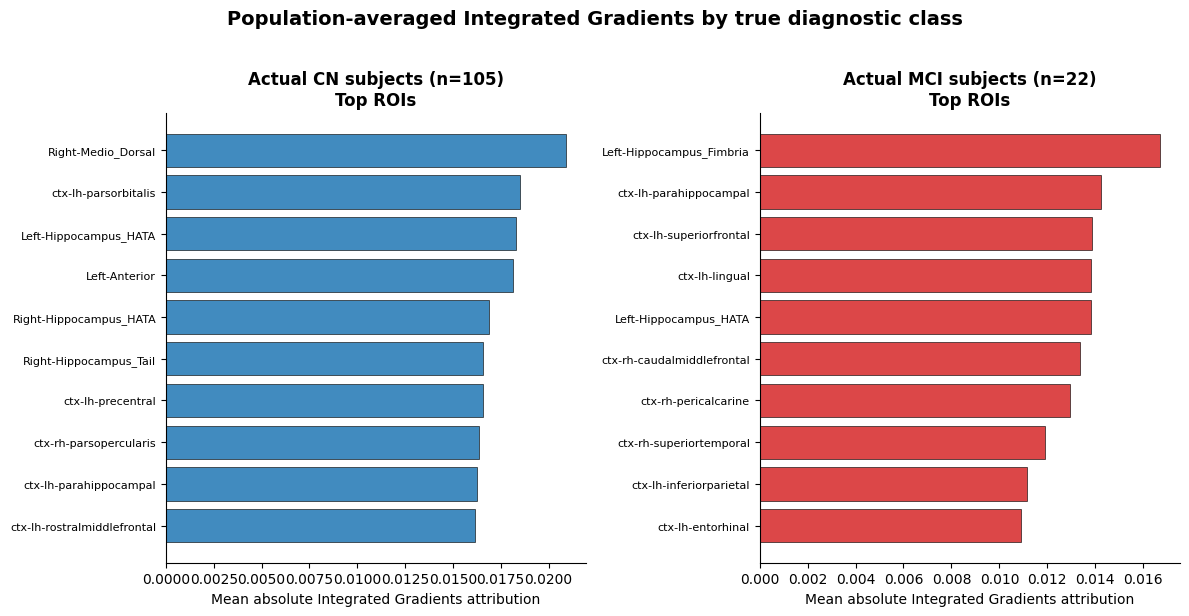

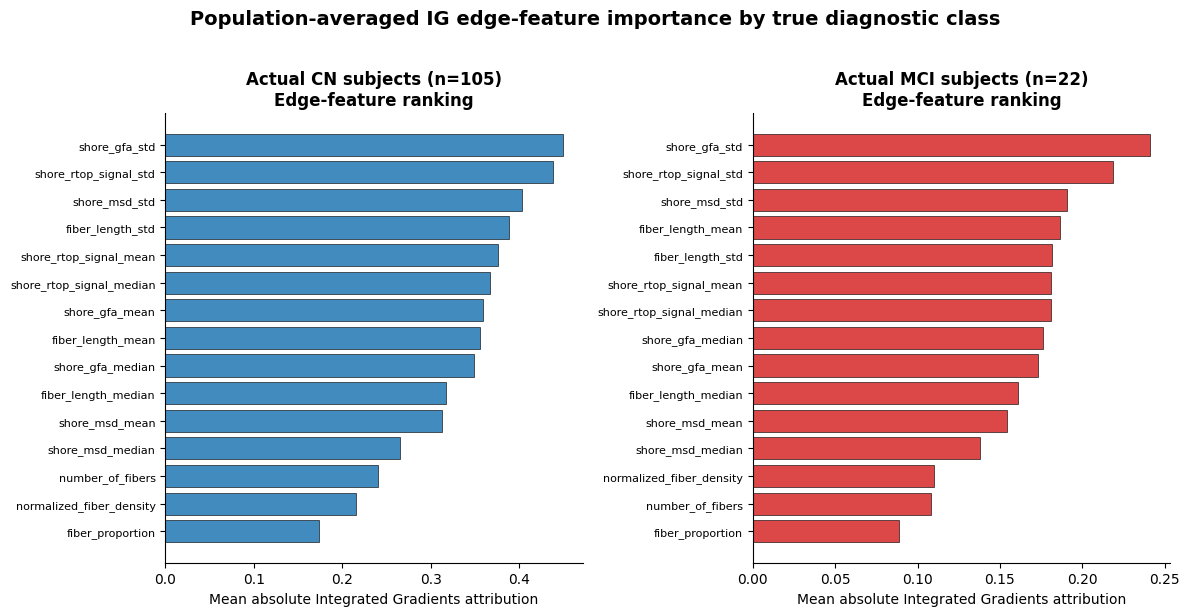

In [24]:
# Per-class Integrated Gradients plots using true labels


CLASS_COLORS = {
    'CN': '#1f77b4',
    'MCI': '#d62728',
}


def plot_true_class_ig_nodes(class_node_tables, class_results, top_n=10):
    available_classes = [c for c in ['CN', 'MCI'] if c in class_node_tables]

    if not available_classes:
        print('No true-label class node tables available to plot.')
        return

    fig, axes = plt.subplots(
        1,
        len(available_classes),
        figsize=(6 * len(available_classes), 6),
    )

    if len(available_classes) == 1:
        axes = [axes]

    for ax, class_name in zip(axes, available_classes):
        table = class_node_tables[class_name].head(top_n).iloc[::-1]
        color = CLASS_COLORS.get(class_name, None)

        ax.barh(
            table['region'],
            table['mean_ig_node_score'],
            color=color,
            alpha=0.85,
            edgecolor='black',
            linewidth=0.5,
        )

        ax.set_xlabel('Mean absolute Integrated Gradients attribution')
        ax.set_title(
            f'Actual {class_name} subjects (n={class_results[class_name]["n"]})\nTop ROIs',
            fontsize=12,
            fontweight='bold',
        )

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='y', labelsize=8)

    plt.suptitle(
        'Population-averaged Integrated Gradients by true diagnostic class',
        fontsize=14,
        fontweight='bold',
        y=1.02,
    )

    plt.tight_layout()
    plt.show()


def plot_true_class_ig_edge_features(class_edge_feature_tables, class_results, top_n=15):
    available_classes = [c for c in ['CN', 'MCI'] if c in class_edge_feature_tables]

    if not available_classes:
        print('No true-label class edge-feature tables available to plot.')
        return

    fig, axes = plt.subplots(
        1,
        len(available_classes),
        figsize=(6 * len(available_classes), 6),
    )

    if len(available_classes) == 1:
        axes = [axes]

    for ax, class_name in zip(axes, available_classes):
        table = class_edge_feature_tables[class_name].head(top_n).iloc[::-1]
        color = CLASS_COLORS.get(class_name, None)

        ax.barh(
            table['edge_feature_name'],
            table['mean_ig_edge_feature_score'],
            color=color,
            alpha=0.85,
            edgecolor='black',
            linewidth=0.5,
        )

        ax.set_xlabel('Mean absolute Integrated Gradients attribution')
        ax.set_title(
            f'Actual {class_name} subjects (n={class_results[class_name]["n"]})\nEdge-feature ranking',
            fontsize=12,
            fontweight='bold',
        )

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='y', labelsize=8)

    plt.suptitle(
        'Population-averaged IG edge-feature importance by true diagnostic class',
        fontsize=14,
        fontweight='bold',
        y=1.02,
    )

    plt.tight_layout()
    plt.show()


plot_true_class_ig_nodes(
    class_population_node_tables,
    class_ig_results,
    top_n=10,
)

plot_true_class_ig_edge_features(
    class_population_edge_feature_tables,
    class_ig_results,
    top_n=15,
)

In [25]:
# Signed node Integrated Gradients toward MCI


MCI_CLASS_ID = 1


def make_signed_node_ig_table(
    g,
    ig_result,
    subject_id=None,
    test_index=None,
    true_label=None,
    pred_label=None,
):
    """
    Creates a node-level signed IG table.

    signed_node_ig_MCI:
        Sum of signed Integrated Gradients over all node features for each node,
        using target_class = MCI.

    Interpretation:
        positive -> node contributes toward the MCI logit
        negative -> node contributes against the MCI logit / toward CN
    """
    ig_x = ig_result['ig_x'].detach().cpu()

    signed_node_scores = ig_x.sum(dim=-1)
    abs_node_scores = ig_x.abs().sum(dim=-1)
    positive_node_scores = torch.clamp(ig_x, min=0).sum(dim=-1)
    negative_node_scores = torch.clamp(ig_x, max=0).sum(dim=-1)

    rows = []

    for node_idx in range(ig_x.size(0)):
        feature_scores = ig_x[node_idx]
        top_feature_idx = int(torch.argmax(feature_scores.abs()).item())
        signed_score = float(signed_node_scores[node_idx].item())

        if signed_score > 0:
            direction = 'supports_MCI'
        elif signed_score < 0:
            direction = 'supports_CN'
        else:
            direction = 'neutral'

        rows.append({
            'subject_id': subject_id,
            'test_index': test_index,
            'true_label': true_label,
            'pred_label': pred_label,
            'true_class_name': CLASS_NAMES.get(true_label, str(true_label)),
            'pred_class_name': CLASS_NAMES.get(pred_label, str(pred_label)),
            'node_index': int(node_idx),
            'region': node_label(node_idx),
            'signed_node_ig_MCI': signed_score,
            'abs_node_ig_MCI': float(abs_node_scores[node_idx].item()),
            'positive_node_ig_MCI': float(positive_node_scores[node_idx].item()),
            'negative_node_ig_MCI': float(negative_node_scores[node_idx].item()),
            'direction': direction,
            'top_signed_feature_index': top_feature_idx,
            'top_signed_feature_name': (
                NODE_FEATURE_NAMES[top_feature_idx]
                if top_feature_idx < len(NODE_FEATURE_NAMES)
                else f'Node feature {top_feature_idx}'
            ),
            'top_signed_feature_ig': float(feature_scores[top_feature_idx].item()),
            'target_class': 'MCI',
            'target_score': ig_result['target_score'],
            'baseline_score': ig_result['baseline_score'],
        })

    return (
        pd.DataFrame(rows)
        .sort_values('abs_node_ig_MCI', ascending=False)
        .reset_index(drop=True)
    )


signed_node_ig_tables = []
signed_node_ig_failures = []

for _, row in predictions_df.iterrows():
    test_idx = int(row['test_index'])
    subject_id = row['subject_id']
    true = int(row['true_label'])
    pred = int(row['pred_label'])
    g = test_graphs[test_idx].to(DEVICE)

    try:
        # Fixed target: MCI.
        # This makes the sign interpretation consistent for every subject.
        ig_result_mci = run_integrated_gradients(
            g,
            steps=IG_STEPS,
            target_class=MCI_CLASS_ID,
        )

        signed_table = make_signed_node_ig_table(
            g=g,
            ig_result=ig_result_mci,
            subject_id=subject_id,
            test_index=test_idx,
            true_label=true,
            pred_label=pred,
        )

        signed_node_ig_tables.append(signed_table)

    except Exception as e:
        signed_node_ig_failures.append((subject_id, test_idx, str(e)))
        print(f'Signed MCI IG failed for subject {subject_id}, test_index={test_idx}: {e}')


all_signed_node_ig_df = (
    pd.concat(signed_node_ig_tables, ignore_index=True)
    if signed_node_ig_tables
    else pd.DataFrame()
)

print('Signed node IG toward MCI complete.')
print(
    f'Successful subjects: '
    f'{all_signed_node_ig_df["subject_id"].nunique() if not all_signed_node_ig_df.empty else 0}'
)
print(f'Failures: {len(signed_node_ig_failures)}')

display(all_signed_node_ig_df.head(15))

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Signed node IG toward MCI complete.
Successful subjects: 127
Failures: 0


,subject_id,test_index,true_label,pred_label,true_class_name,pred_class_name,node_index,region,signed_node_ig_MCI,abs_node_ig_MCI,positive_node_ig_MCI,negative_node_ig_MCI,direction,top_signed_feature_index,top_signed_feature_name,top_signed_feature_ig,target_class,target_score,baseline_score
0,OAS30002,0,0,0,CN,CN,99,ctx-lh-parahippocampal,0.034331,0.055497,0.044914,-0.010583,supports_MCI,0,volume,0.033281,MCI,-0.332808,-0.003149
1,OAS30002,0,0,0,CN,CN,66,Right-Hippocampus_HATA,-0.041693,0.042210,0.000259,-0.041951,supports_CN,2,has_volume,-0.028009,MCI,-0.332808,-0.003149
2,OAS30002,0,0,0,CN,CN,10,ctx-rh-insula,-0.029747,0.029747,0.000000,-0.029747,supports_CN,0,volume,-0.017772,MCI,-0.332808,-0.003149
3,OAS30002,0,0,0,CN,CN,77,Left-Hippocampus_Tail,0.013622,0.024750,0.019186,-0.005564,supports_MCI,1,thickness,0.011647,MCI,-0.332808,-0.003149
4,OAS30002,0,0,0,CN,CN,18,ctx-lh-caudalanteriorcingulate,-0.019359,0.022621,0.001631,-0.020990,supports_CN,3,has_thickness,-0.010822,MCI,-0.332808,-0.003149
5,OAS30002,0,0,0,CN,CN,94,ctx-lh-frontalpole,0.001783,0.006299,0.004041,-0.002258,supports_MCI,2,has_volume,0.003846,MCI,-0.332808,-0.003149
6,OAS30002,0,0,0,CN,CN,22,ctx-lh-medialorbitofrontal,-0.005991,0.006201,0.000105,-0.006096,supports_CN,0,volume,-0.003281,MCI,-0.332808,-0.003149
7,OAS30002,0,0,0,CN,CN,63,ctx-lh-parsopercularis,-0.005890,0.005906,0.000008,-0.005898,supports_CN,3,has_thickness,-0.003152,MCI,-0.332808,-0.003149
8,OAS30002,0,0,0,CN,CN,107,ctx-lh-entorhinal,-0.005776,0.005776,0.000000,-0.005776,supports_CN,3,has_thickness,-0.005193,MCI,-0.332808,-0.003149
9,OAS30002,0,0,0,CN,CN,108,Left-Hippocampus_Fimbria,0.000332,0.005618,0.002975,-0.002643,supports_MCI,3,has_thickness,0.002963,MCI,-0.332808,-0.003149


In [26]:
# Signed node IG summary by TRUE class


SIGNED_CLASS_GROUP_COL = 'true_class_name'


def summarize_signed_node_ig_by_class(signed_df, class_col='true_class_name'):
    if signed_df.empty:
        return pd.DataFrame()

    summary = (
        signed_df
        .groupby([class_col, 'node_index', 'region'], as_index=False)
        .agg(
            mean_signed_node_ig_MCI=('signed_node_ig_MCI', 'mean'),
            std_signed_node_ig_MCI=('signed_node_ig_MCI', 'std'),
            mean_abs_node_ig_MCI=('abs_node_ig_MCI', 'mean'),
            mean_positive_node_ig_MCI=('positive_node_ig_MCI', 'mean'),
            mean_negative_node_ig_MCI=('negative_node_ig_MCI', 'mean'),
            n_subjects=('subject_id', 'nunique'),
            n_supports_MCI=('direction', lambda x: int((x == 'supports_MCI').sum())),
            n_supports_CN=('direction', lambda x: int((x == 'supports_CN').sum())),
        )
        .reset_index(drop=True)
    )

    summary['dominant_direction'] = np.where(
        summary['mean_signed_node_ig_MCI'] > 0,
        'supports_MCI',
        np.where(
            summary['mean_signed_node_ig_MCI'] < 0,
            'supports_CN',
            'neutral',
        ),
    )

    summary = summary.sort_values(
        [class_col, 'mean_abs_node_ig_MCI'],
        ascending=[True, False],
    ).reset_index(drop=True)

    return summary


signed_node_ig_class_summary_df = summarize_signed_node_ig_by_class(
    all_signed_node_ig_df,
    class_col=SIGNED_CLASS_GROUP_COL,
)

print(f'Signed node IG summary grouped by {SIGNED_CLASS_GROUP_COL}:')
display(
    signed_node_ig_class_summary_df
    .groupby(SIGNED_CLASS_GROUP_COL)
    .head(15)
)


print('Top nodes with positive signed contribution toward MCI:')
display(
    signed_node_ig_class_summary_df
    .sort_values(
        [SIGNED_CLASS_GROUP_COL, 'mean_signed_node_ig_MCI'],
        ascending=[True, False],
    )
    .groupby(SIGNED_CLASS_GROUP_COL)
    .head(10)
)


print('Top nodes with negative signed contribution toward MCI:')
display(
    signed_node_ig_class_summary_df
    .sort_values(
        [SIGNED_CLASS_GROUP_COL, 'mean_signed_node_ig_MCI'],
        ascending=[True, True],
    )
    .groupby(SIGNED_CLASS_GROUP_COL)
    .head(10)
)

Signed node IG summary grouped by true_class_name:


,true_class_name,node_index,region,mean_signed_node_ig_MCI,std_signed_node_ig_MCI,mean_abs_node_ig_MCI,mean_positive_node_ig_MCI,mean_negative_node_ig_MCI,n_subjects,n_supports_MCI,n_supports_CN,dominant_direction
0,CN,31,Right-Medio_Dorsal,0.003225,0.040845,0.010553,0.006889,-0.003664,105,37,68,supports_MCI
1,CN,66,Right-Hippocampus_HATA,-0.000277,0.016660,0.009906,0.004815,-0.005091,105,30,75,supports_CN
2,CN,99,ctx-lh-parahippocampal,0.000204,0.023197,0.009466,0.004835,-0.004631,105,38,67,supports_MCI
3,CN,51,ctx-lh-precentral,-0.000553,0.010665,0.009308,0.004377,-0.004931,105,34,71,supports_CN
4,CN,90,Right-Hippocampus_Tail,-0.002170,0.018103,0.009111,0.003471,-0.005641,105,32,73,supports_CN
5,CN,69,ctx-rh-isthmuscingulate,-0.000919,0.009319,0.008829,0.003955,-0.004874,105,38,67,supports_CN
6,CN,35,ctx-lh-parsorbitalis,-0.000296,0.015421,0.008299,0.004002,-0.004297,105,43,62,supports_CN
7,CN,18,ctx-lh-caudalanteriorcingulate,0.000425,0.020598,0.008176,0.004301,-0.003875,105,36,69,supports_MCI
8,CN,89,Right-Hippocampus_Hippocampal_fissure,-0.001971,0.017570,0.008030,0.003029,-0.005000,105,38,67,supports_CN
9,CN,48,ctx-rh-supramarginal,-0.003862,0.027411,0.008019,0.002078,-0.005941,105,28,77,supports_CN


Top nodes with positive signed contribution toward MCI:


,true_class_name,node_index,region,mean_signed_node_ig_MCI,std_signed_node_ig_MCI,mean_abs_node_ig_MCI,mean_positive_node_ig_MCI,mean_negative_node_ig_MCI,n_subjects,n_supports_MCI,n_supports_CN,dominant_direction
0,CN,31,Right-Medio_Dorsal,0.003225,0.040845,0.010553,0.006889,-0.003664,105,37,68,supports_MCI
17,CN,15,ctx-rh-parsopercularis,0.002260,0.019835,0.007437,0.004849,-0.002589,105,51,54,supports_MCI
12,CN,23,Brain_Stem-Midbrain,0.001608,0.013833,0.007643,0.004626,-0.003018,105,41,64,supports_MCI
29,CN,106,Left-Hippocampus_HATA,0.001368,0.016640,0.006760,0.004064,-0.002696,105,44,61,supports_MCI
64,CN,104,ctx-lh-transversetemporal,0.001029,0.009597,0.005712,0.003371,-0.002341,105,43,62,supports_MCI
27,CN,24,ctx-rh-posteriorcingulate,0.001008,0.013410,0.006830,0.003919,-0.002911,105,44,61,supports_MCI
10,CN,61,Left-Ventral_Latero_Ventral,0.000765,0.013351,0.007942,0.004354,-0.003589,105,39,66,supports_MCI
46,CN,87,ctx-lh-temporalpole,0.000705,0.011234,0.006136,0.003420,-0.002716,105,37,68,supports_MCI
55,CN,36,ctx-rh-caudalmiddlefrontal,0.000668,0.012242,0.005927,0.003297,-0.002629,105,34,71,supports_MCI
39,CN,32,Right-Hippocampus,0.000631,0.012189,0.006376,0.003504,-0.002872,105,46,59,supports_MCI


Top nodes with negative signed contribution toward MCI:


,true_class_name,node_index,region,mean_signed_node_ig_MCI,std_signed_node_ig_MCI,mean_abs_node_ig_MCI,mean_positive_node_ig_MCI,mean_negative_node_ig_MCI,n_subjects,n_supports_MCI,n_supports_CN,dominant_direction
21,CN,0,ctx-rh-lateralorbitofrontal,-0.005449,0.014886,0.007036,0.000794,-0.006242,105,29,76,supports_CN
9,CN,48,ctx-rh-supramarginal,-0.003862,0.027411,0.008019,0.002078,-0.005941,105,28,77,supports_CN
31,CN,95,Left-Pulvinar,-0.003460,0.014276,0.006584,0.001562,-0.005022,105,30,75,supports_CN
28,CN,43,Right-Central_Lateral-Lateral_Posterior-Medial...,-0.003431,0.013161,0.006798,0.001684,-0.005115,105,27,78,supports_CN
16,CN,29,Left-Caudate,-0.003058,0.025914,0.007478,0.002210,-0.005268,105,36,69,supports_CN
59,CN,107,ctx-lh-entorhinal,-0.002832,0.011358,0.005770,0.001469,-0.004301,105,27,78,supports_CN
42,CN,67,ctx-lh-superiorparietal,-0.002754,0.007509,0.006270,0.001758,-0.004512,105,35,70,supports_CN
82,CN,91,ctx-lh-pericalcarine,-0.002742,0.011642,0.005220,0.001239,-0.003981,105,33,72,supports_CN
58,CN,1,Right-Putamen,-0.002569,0.012362,0.005839,0.001635,-0.004204,105,48,57,supports_CN
57,CN,83,Left-Hippocampus,-0.002561,0.008344,0.005874,0.001657,-0.004218,105,25,80,supports_CN


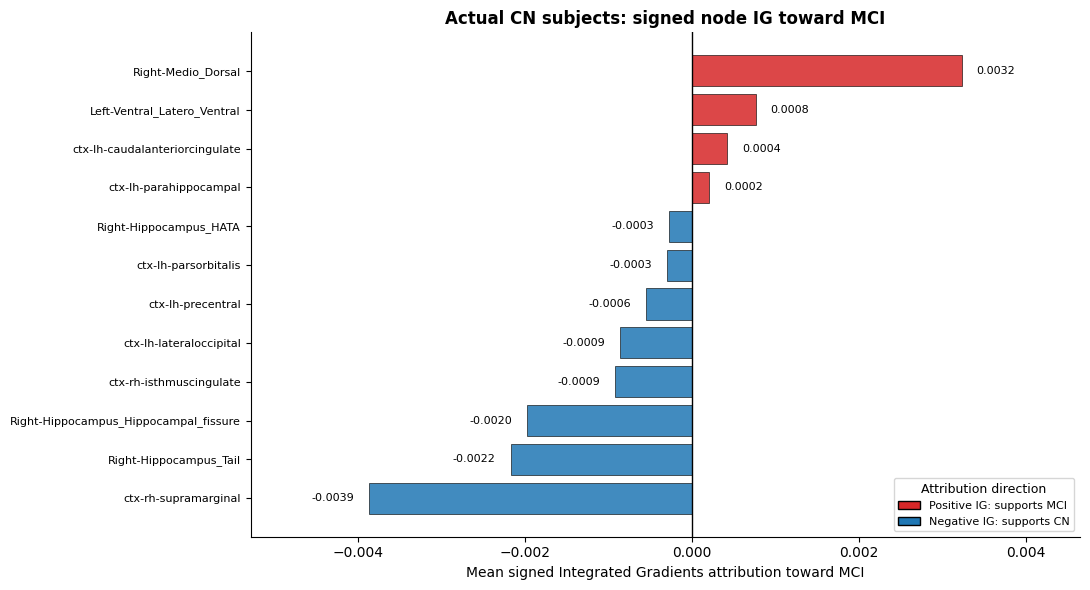

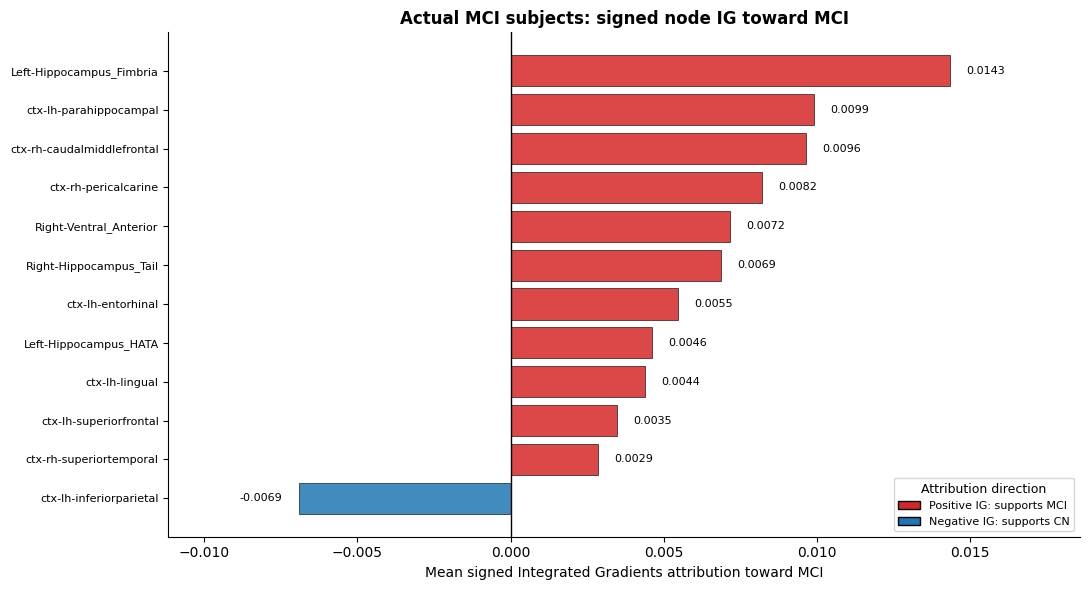

In [29]:
from matplotlib.patches import Patch

# Signed node IG plots by TRUE class

def plot_signed_node_ig_by_true_class(summary_df, class_col='true_class_name', top_n=12):
    if summary_df.empty:
        print('No signed node IG summary to plot.')
        return

    available_classes = [c for c in ['CN', 'MCI'] if c in summary_df[class_col].unique()]

    if not available_classes:
        print('No true-label class groups available to plot.')
        return

    for class_name in available_classes:
        class_df = summary_df[summary_df[class_col] == class_name].copy()

        plot_df = (
            class_df
            .sort_values('mean_abs_node_ig_MCI', ascending=False)
            .head(top_n)
            .sort_values('mean_signed_node_ig_MCI', ascending=True)
        )

        colors = plot_df['mean_signed_node_ig_MCI'].apply(
            lambda x: '#d62728' if x > 0 else '#1f77b4'
        )

        fig, ax = plt.subplots(figsize=(11, 6))

        bars = ax.barh(
            plot_df['region'],
            plot_df['mean_signed_node_ig_MCI'],
            color=colors,
            alpha=0.85,
            edgecolor='black',
            linewidth=0.5,
        )

        ax.axvline(0, color='black', linewidth=1.0)
        ax.set_xlabel('Mean signed Integrated Gradients attribution toward MCI')

        # Cleaner title now that the explanation is in the legend
        ax.set_title(
            f'Actual {class_name} subjects: signed node IG toward MCI',
            fontsize=12,
            fontweight='bold',
        )

        # Legend / color key
        legend_elements = [
            Patch(facecolor='#d62728', edgecolor='black', label='Positive IG: supports MCI'),
            Patch(facecolor='#1f77b4', edgecolor='black', label='Negative IG: supports CN'),
        ]

        ax.legend(
            handles=legend_elements,
            loc='lower right',
            frameon=True,
            fontsize=8,
            title='Attribution direction',
            title_fontsize=9,
        )

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='y', labelsize=8)

        values = plot_df['mean_signed_node_ig_MCI']
        x_min = values.min()
        x_max = values.max()
        x_range = x_max - x_min if x_max != x_min else max(abs(x_max), 1e-3)

        padding = 0.20 * x_range
        ax.set_xlim(x_min - padding, x_max + padding)

        label_offset = 0.025 * x_range

        for bar, value in zip(bars, values):
            x_pos = bar.get_width()

            if value >= 0:
                label_x = x_pos + label_offset
                ha = 'left'
            else:
                label_x = x_pos - label_offset
                ha = 'right'

            ax.text(
                label_x,
                bar.get_y() + bar.get_height() / 2,
                f'{value:.4f}',
                va='center',
                ha=ha,
                fontsize=8,
                clip_on=False,
            )

        plt.tight_layout()
        plt.show()


plot_signed_node_ig_by_true_class(
    signed_node_ig_class_summary_df,
    class_col=SIGNED_CLASS_GROUP_COL,
    top_n=12,
)

In [28]:
#Combined signed and absolute node IG table


combined_signed_ig_df = signed_node_ig_class_summary_df.copy()

combined_signed_ig_df['signed_direction_strength'] = (
    combined_signed_ig_df['mean_signed_node_ig_MCI']
)

combined_signed_ig_df['absolute_importance_strength'] = (
    combined_signed_ig_df['mean_abs_node_ig_MCI']
)

combined_signed_ig_df = combined_signed_ig_df.sort_values(
    [SIGNED_CLASS_GROUP_COL, 'absolute_importance_strength'],
    ascending=[True, False],
).reset_index(drop=True)


print('Most important signed nodes by true class:')
display(
    combined_signed_ig_df
    .groupby(SIGNED_CLASS_GROUP_COL)
    .head(15)
)


print('Strongest MCI-supporting nodes by true class:')
display(
    combined_signed_ig_df
    .sort_values(
        [SIGNED_CLASS_GROUP_COL, 'signed_direction_strength'],
        ascending=[True, False],
    )
    .groupby(SIGNED_CLASS_GROUP_COL)
    .head(10)
)


print('Strongest CN-supporting / MCI-opposing nodes by true class:')
display(
    combined_signed_ig_df
    .sort_values(
        [SIGNED_CLASS_GROUP_COL, 'signed_direction_strength'],
        ascending=[True, True],
    )
    .groupby(SIGNED_CLASS_GROUP_COL)
    .head(10)
)

Most important signed nodes by true class:


,true_class_name,node_index,region,mean_signed_node_ig_MCI,std_signed_node_ig_MCI,mean_abs_node_ig_MCI,mean_positive_node_ig_MCI,mean_negative_node_ig_MCI,n_subjects,n_supports_MCI,n_supports_CN,dominant_direction,signed_direction_strength,absolute_importance_strength
0,CN,31,Right-Medio_Dorsal,0.003225,0.040845,0.010553,0.006889,-0.003664,105,37,68,supports_MCI,0.003225,0.010553
1,CN,66,Right-Hippocampus_HATA,-0.000277,0.016660,0.009906,0.004815,-0.005091,105,30,75,supports_CN,-0.000277,0.009906
2,CN,99,ctx-lh-parahippocampal,0.000204,0.023197,0.009466,0.004835,-0.004631,105,38,67,supports_MCI,0.000204,0.009466
3,CN,51,ctx-lh-precentral,-0.000553,0.010665,0.009308,0.004377,-0.004931,105,34,71,supports_CN,-0.000553,0.009308
4,CN,90,Right-Hippocampus_Tail,-0.002170,0.018103,0.009111,0.003471,-0.005641,105,32,73,supports_CN,-0.002170,0.009111
5,CN,69,ctx-rh-isthmuscingulate,-0.000919,0.009319,0.008829,0.003955,-0.004874,105,38,67,supports_CN,-0.000919,0.008829
6,CN,35,ctx-lh-parsorbitalis,-0.000296,0.015421,0.008299,0.004002,-0.004297,105,43,62,supports_CN,-0.000296,0.008299
7,CN,18,ctx-lh-caudalanteriorcingulate,0.000425,0.020598,0.008176,0.004301,-0.003875,105,36,69,supports_MCI,0.000425,0.008176
8,CN,89,Right-Hippocampus_Hippocampal_fissure,-0.001971,0.017570,0.008030,0.003029,-0.005000,105,38,67,supports_CN,-0.001971,0.008030
9,CN,48,ctx-rh-supramarginal,-0.003862,0.027411,0.008019,0.002078,-0.005941,105,28,77,supports_CN,-0.003862,0.008019


Strongest MCI-supporting nodes by true class:


,true_class_name,node_index,region,mean_signed_node_ig_MCI,std_signed_node_ig_MCI,mean_abs_node_ig_MCI,mean_positive_node_ig_MCI,mean_negative_node_ig_MCI,n_subjects,n_supports_MCI,n_supports_CN,dominant_direction,signed_direction_strength,absolute_importance_strength
0,CN,31,Right-Medio_Dorsal,0.003225,0.040845,0.010553,0.006889,-0.003664,105,37,68,supports_MCI,0.003225,0.010553
17,CN,15,ctx-rh-parsopercularis,0.002260,0.019835,0.007437,0.004849,-0.002589,105,51,54,supports_MCI,0.002260,0.007437
12,CN,23,Brain_Stem-Midbrain,0.001608,0.013833,0.007643,0.004626,-0.003018,105,41,64,supports_MCI,0.001608,0.007643
29,CN,106,Left-Hippocampus_HATA,0.001368,0.016640,0.006760,0.004064,-0.002696,105,44,61,supports_MCI,0.001368,0.006760
64,CN,104,ctx-lh-transversetemporal,0.001029,0.009597,0.005712,0.003371,-0.002341,105,43,62,supports_MCI,0.001029,0.005712
27,CN,24,ctx-rh-posteriorcingulate,0.001008,0.013410,0.006830,0.003919,-0.002911,105,44,61,supports_MCI,0.001008,0.006830
10,CN,61,Left-Ventral_Latero_Ventral,0.000765,0.013351,0.007942,0.004354,-0.003589,105,39,66,supports_MCI,0.000765,0.007942
46,CN,87,ctx-lh-temporalpole,0.000705,0.011234,0.006136,0.003420,-0.002716,105,37,68,supports_MCI,0.000705,0.006136
55,CN,36,ctx-rh-caudalmiddlefrontal,0.000668,0.012242,0.005927,0.003297,-0.002629,105,34,71,supports_MCI,0.000668,0.005927
39,CN,32,Right-Hippocampus,0.000631,0.012189,0.006376,0.003504,-0.002872,105,46,59,supports_MCI,0.000631,0.006376


Strongest CN-supporting / MCI-opposing nodes by true class:


,true_class_name,node_index,region,mean_signed_node_ig_MCI,std_signed_node_ig_MCI,mean_abs_node_ig_MCI,mean_positive_node_ig_MCI,mean_negative_node_ig_MCI,n_subjects,n_supports_MCI,n_supports_CN,dominant_direction,signed_direction_strength,absolute_importance_strength
21,CN,0,ctx-rh-lateralorbitofrontal,-0.005449,0.014886,0.007036,0.000794,-0.006242,105,29,76,supports_CN,-0.005449,0.007036
9,CN,48,ctx-rh-supramarginal,-0.003862,0.027411,0.008019,0.002078,-0.005941,105,28,77,supports_CN,-0.003862,0.008019
31,CN,95,Left-Pulvinar,-0.003460,0.014276,0.006584,0.001562,-0.005022,105,30,75,supports_CN,-0.003460,0.006584
28,CN,43,Right-Central_Lateral-Lateral_Posterior-Medial...,-0.003431,0.013161,0.006798,0.001684,-0.005115,105,27,78,supports_CN,-0.003431,0.006798
16,CN,29,Left-Caudate,-0.003058,0.025914,0.007478,0.002210,-0.005268,105,36,69,supports_CN,-0.003058,0.007478
59,CN,107,ctx-lh-entorhinal,-0.002832,0.011358,0.005770,0.001469,-0.004301,105,27,78,supports_CN,-0.002832,0.005770
42,CN,67,ctx-lh-superiorparietal,-0.002754,0.007509,0.006270,0.001758,-0.004512,105,35,70,supports_CN,-0.002754,0.006270
82,CN,91,ctx-lh-pericalcarine,-0.002742,0.011642,0.005220,0.001239,-0.003981,105,33,72,supports_CN,-0.002742,0.005220
58,CN,1,Right-Putamen,-0.002569,0.012362,0.005839,0.001635,-0.004204,105,48,57,supports_CN,-0.002569,0.005839
57,CN,83,Left-Hippocampus,-0.002561,0.008344,0.005874,0.001657,-0.004218,105,25,80,supports_CN,-0.002561,0.005874
